#**Naive Bayes**

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [ ]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.naive_bayes import BernoulliNB,MultinomialNB,GaussianNB
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score,accuracy_score,roc_curve,auc
from sklearn.model_selection import KFold

**Reading Dataset from drive**

In [ ]:
data = pd.read_csv('/content/drive/My Drive/Sem5/ml/a3/spambase_csv.csv')
data.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [ ]:
data.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


#**EDA**

**(i) Missing values**

In [ ]:
data.isnull().sum()

,0
word_freq_make,0
word_freq_address,0
word_freq_all,0
word_freq_3d,0
word_freq_our,0
word_freq_over,0
word_freq_remove,0
word_freq_internet,0
word_freq_order,0
word_freq_mail,0


**(ii) Handle Outliers**

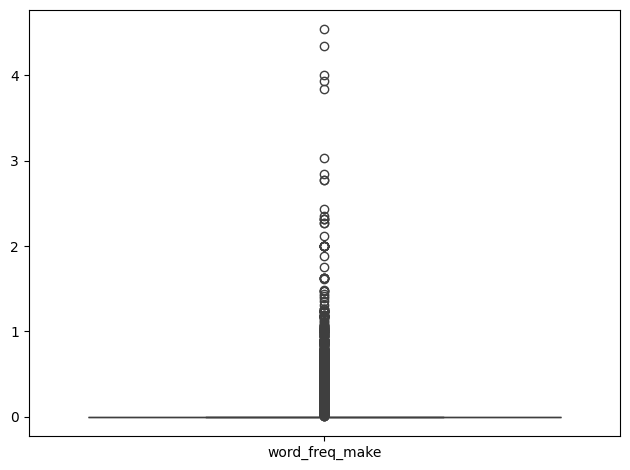

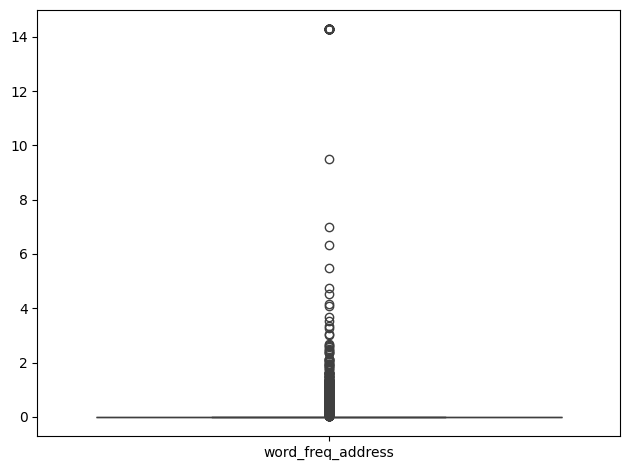

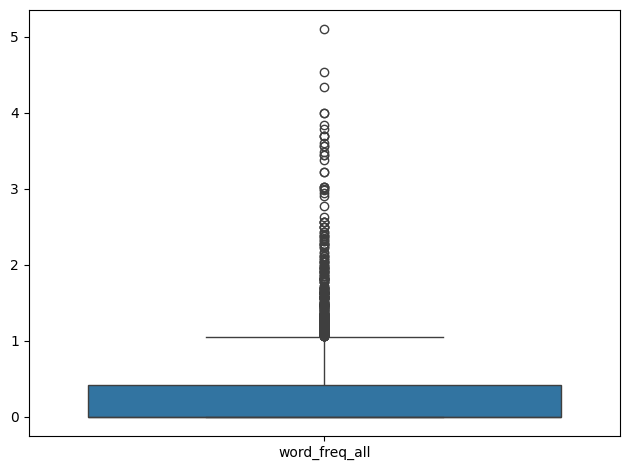

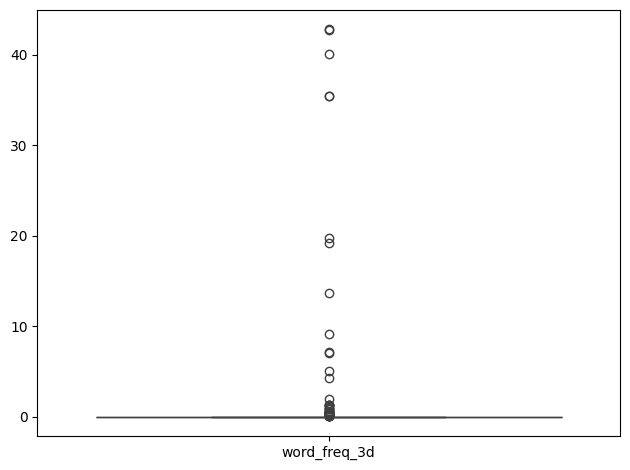

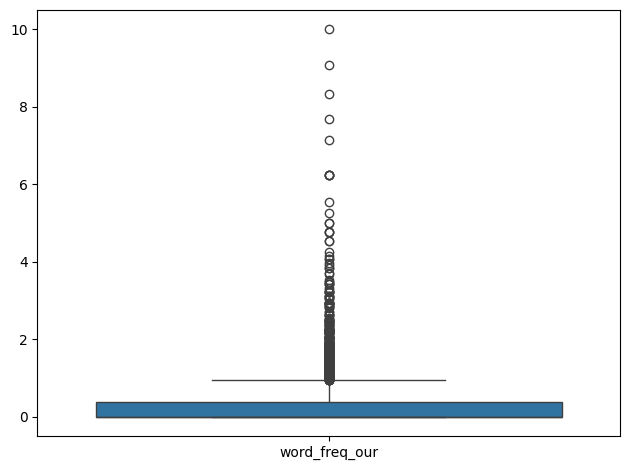

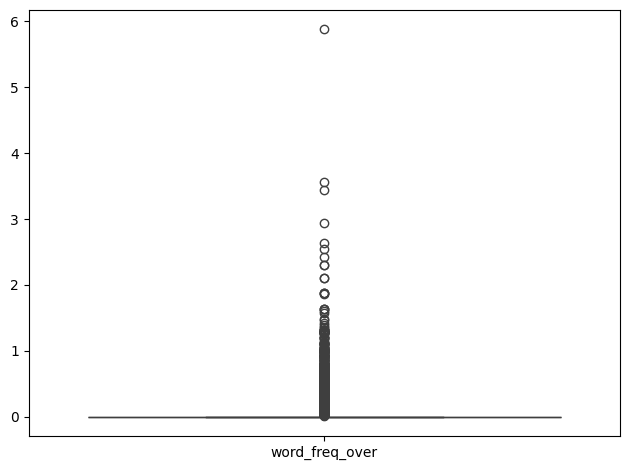

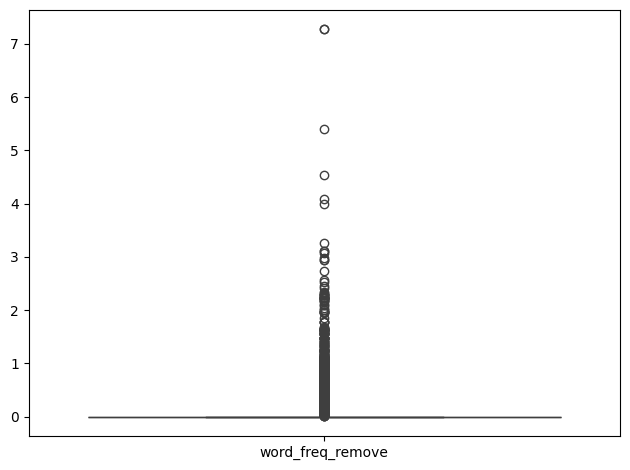

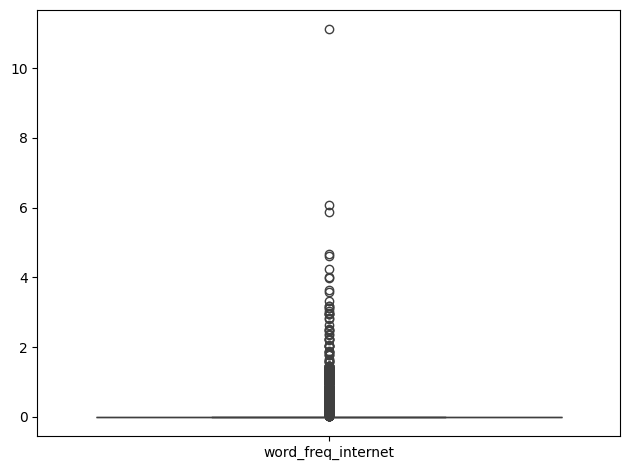

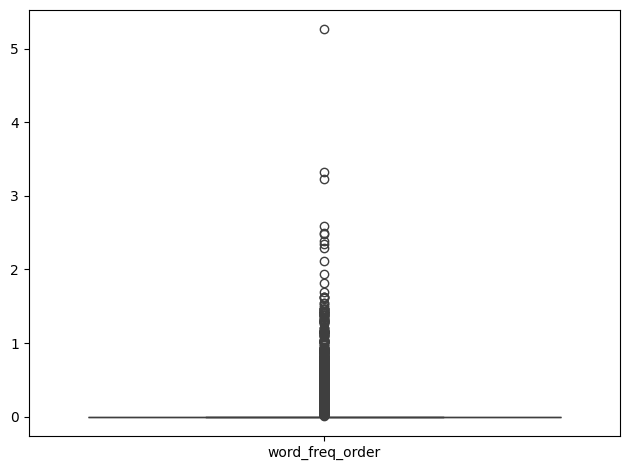

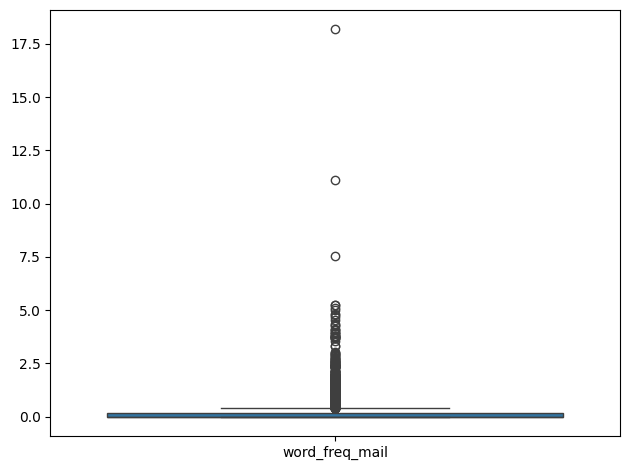

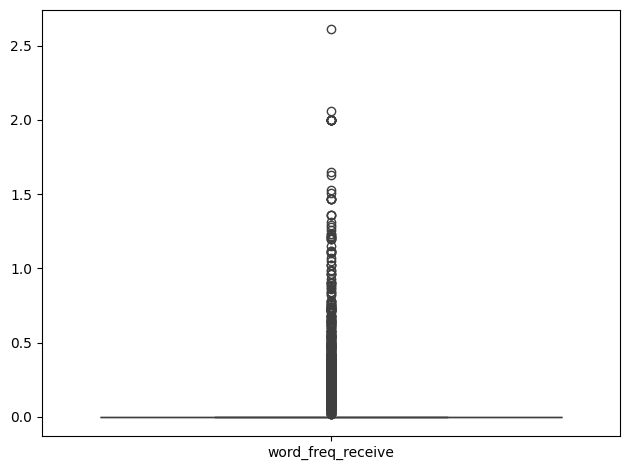

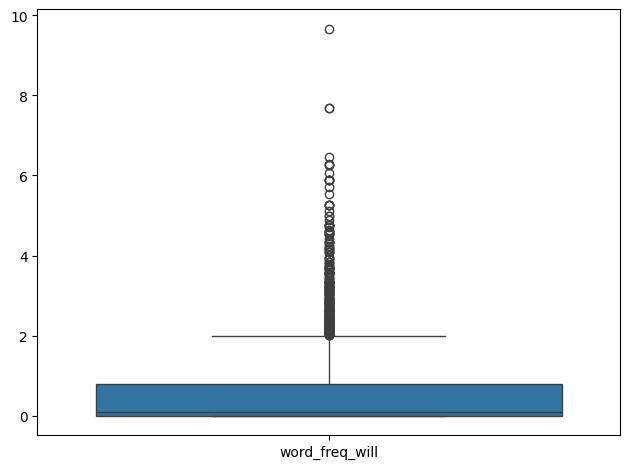

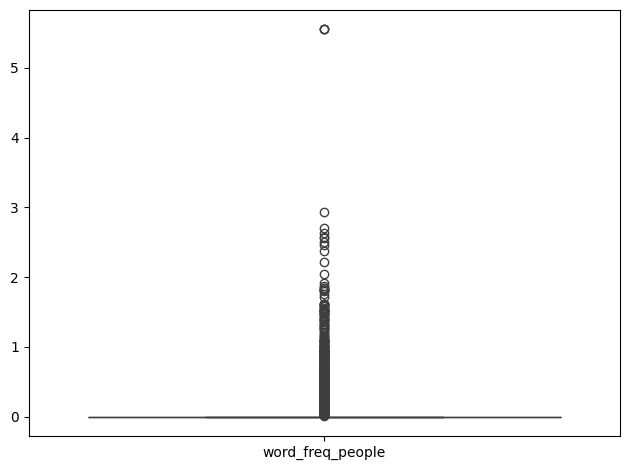

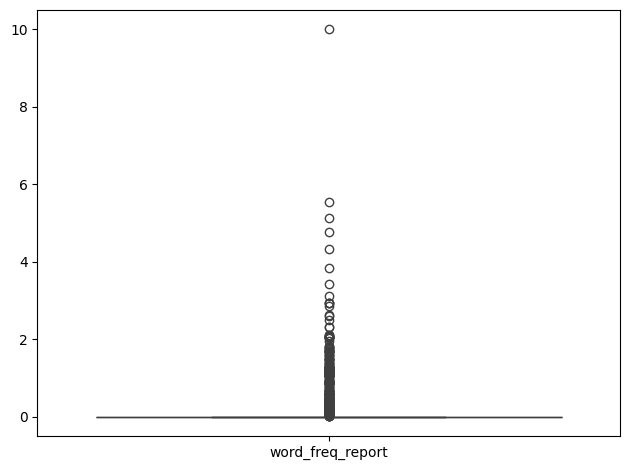

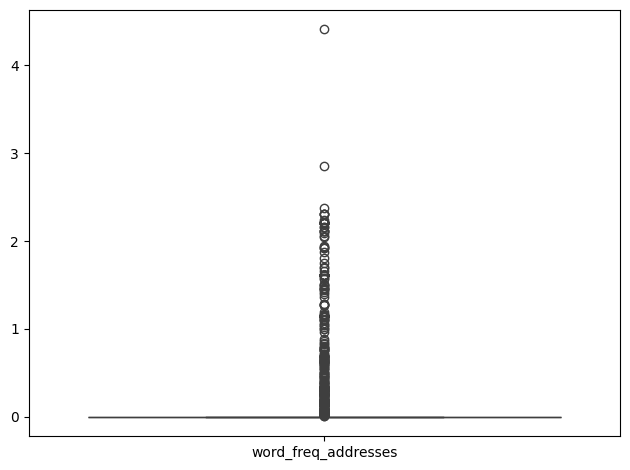

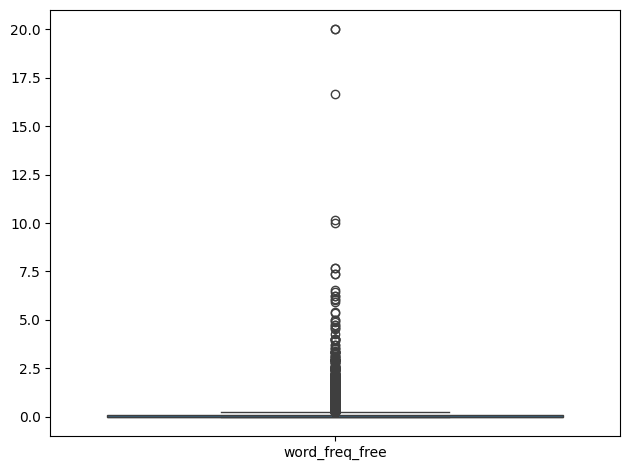

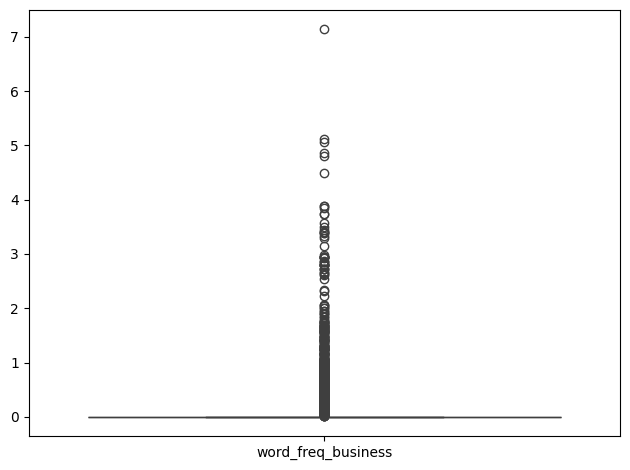

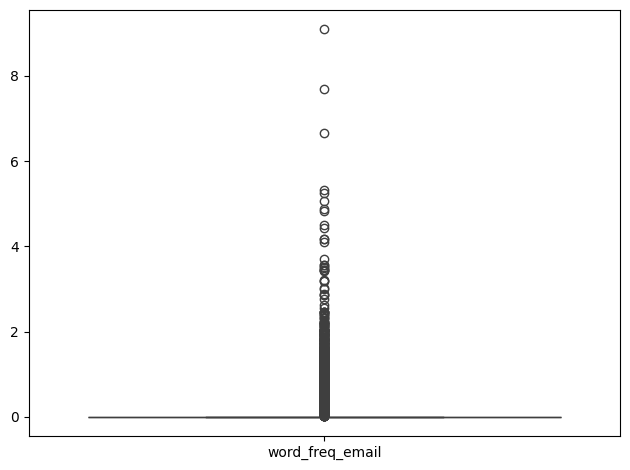

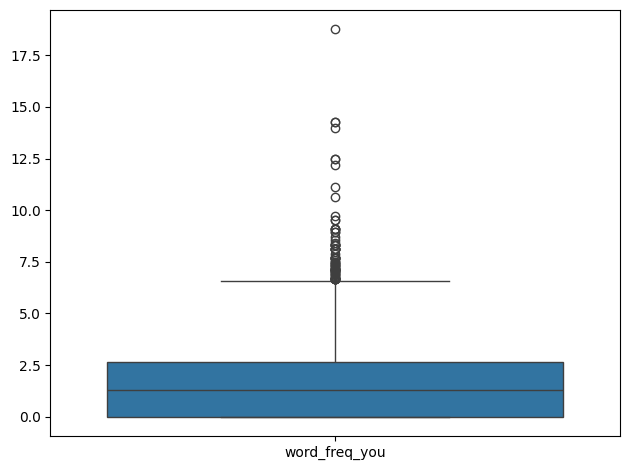

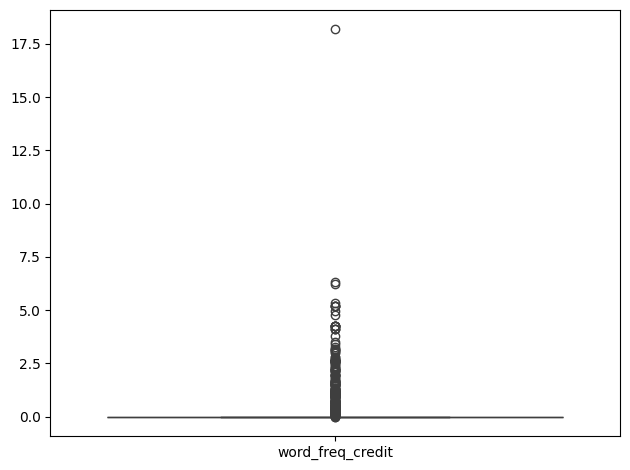

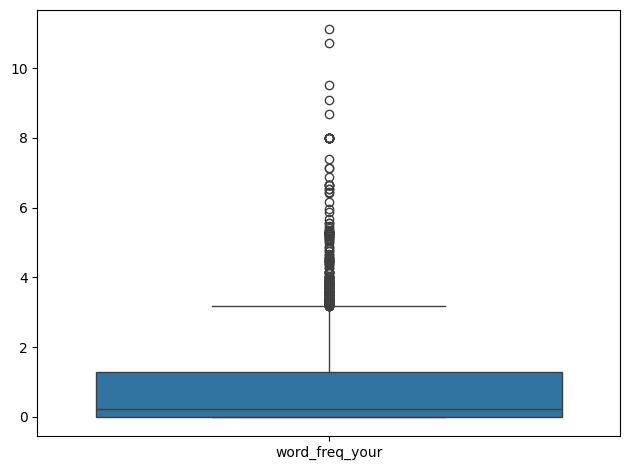

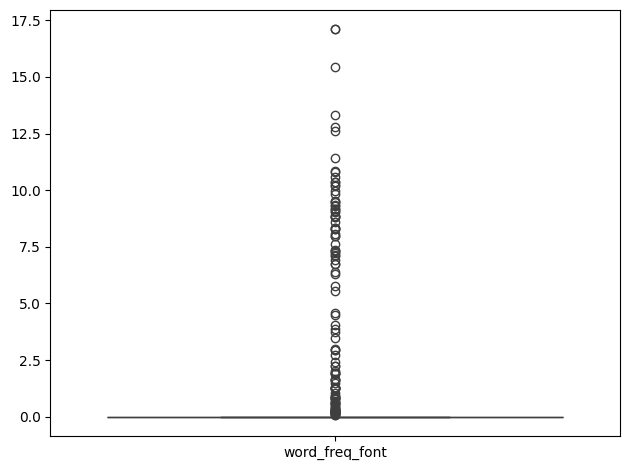

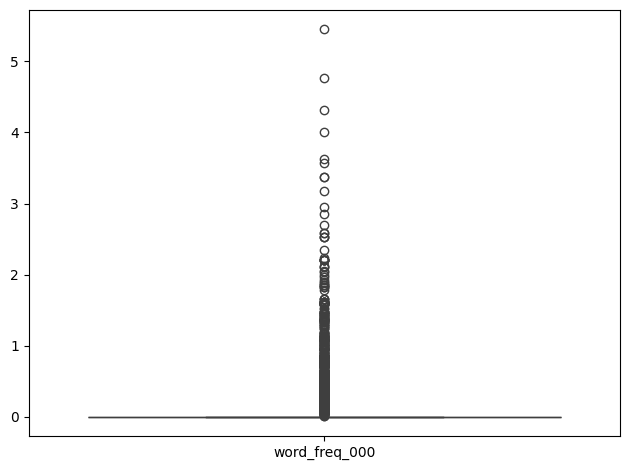

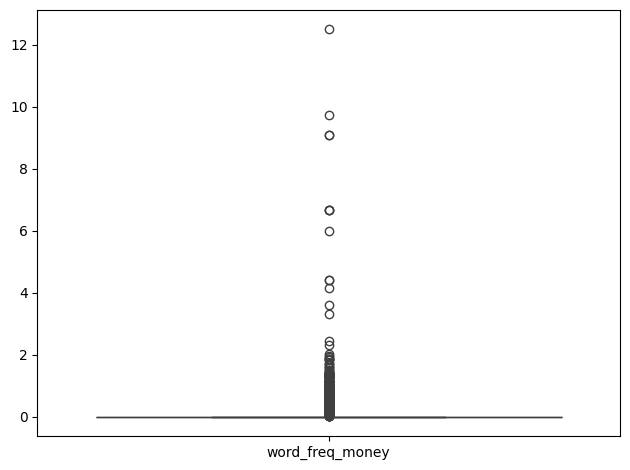

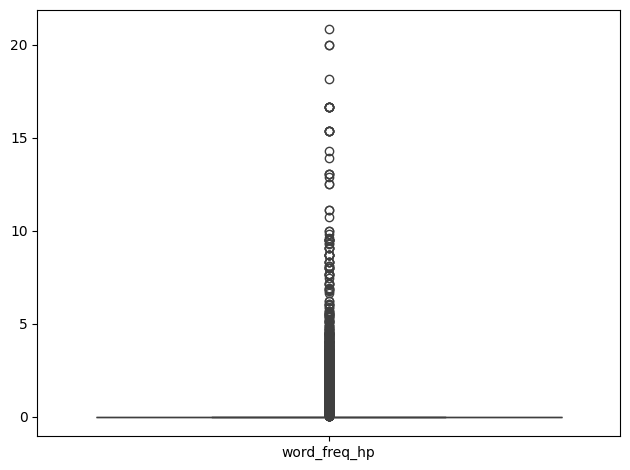

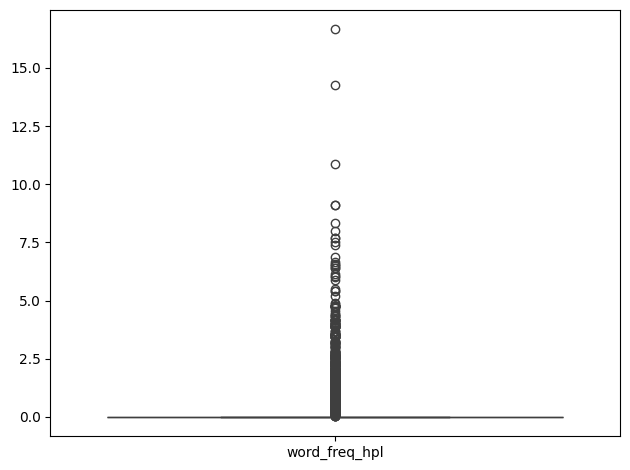

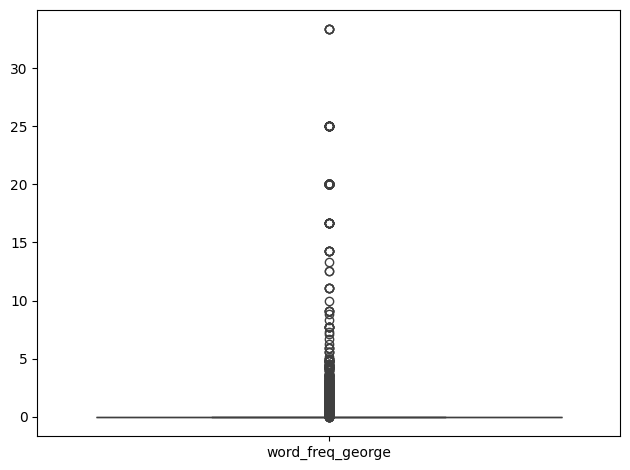

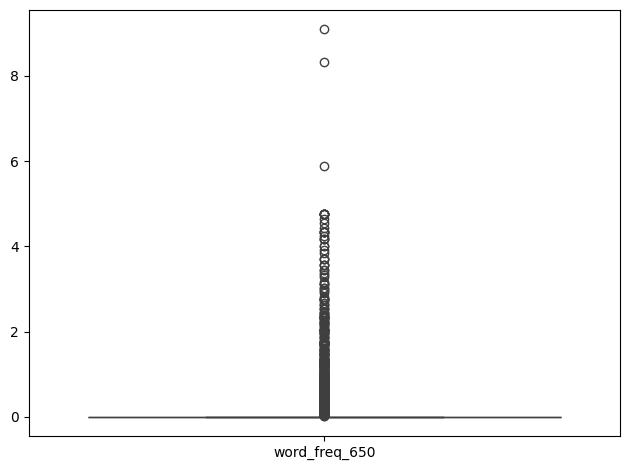

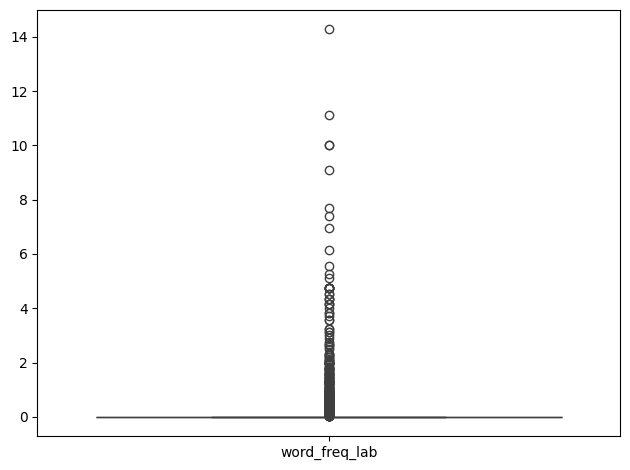

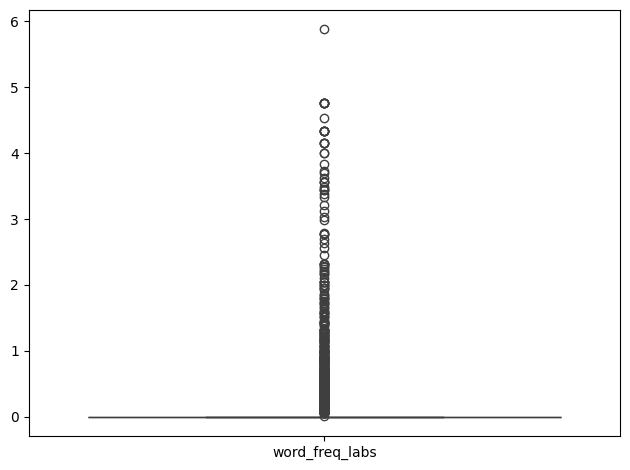

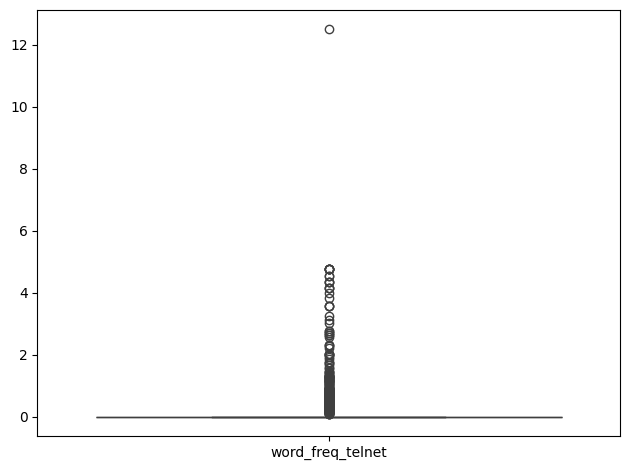

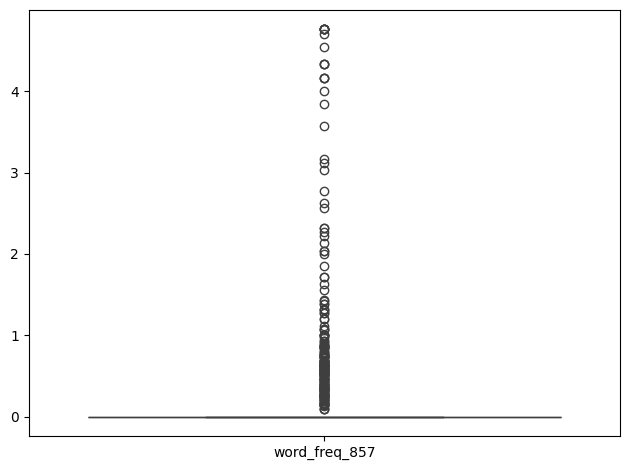

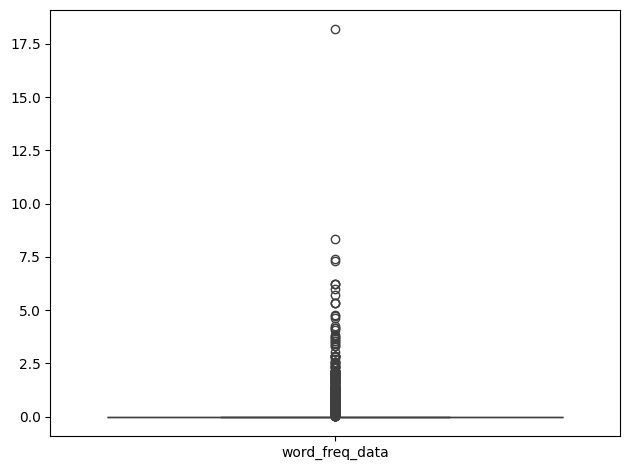

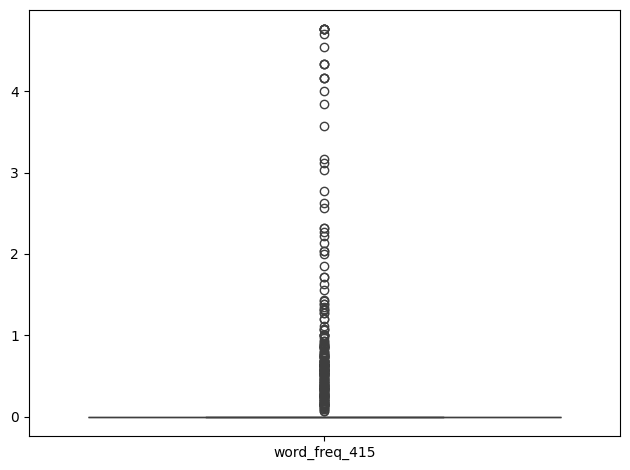

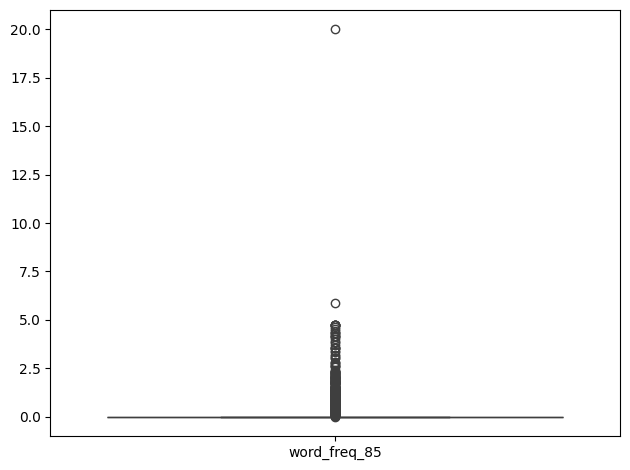

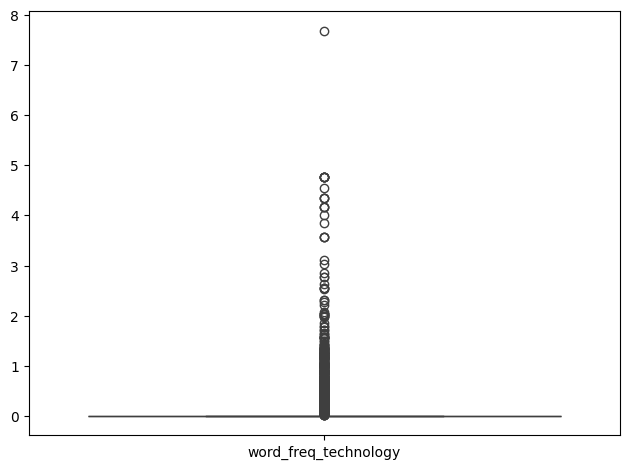

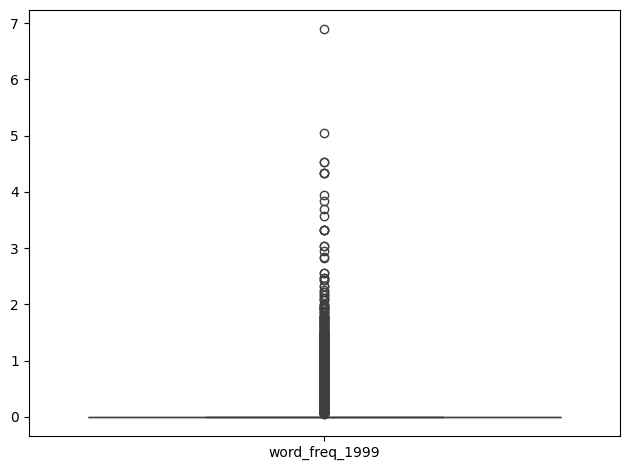

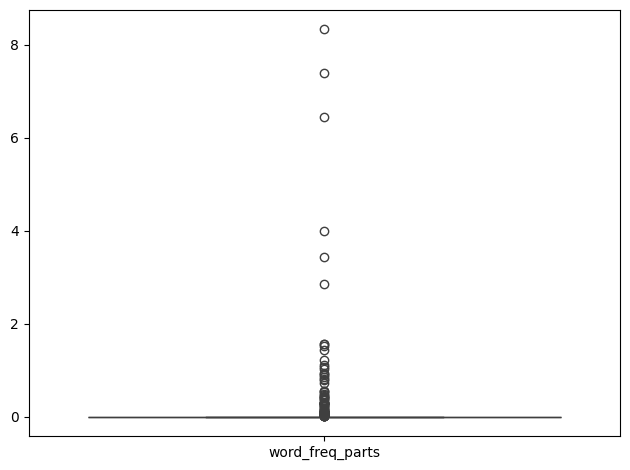

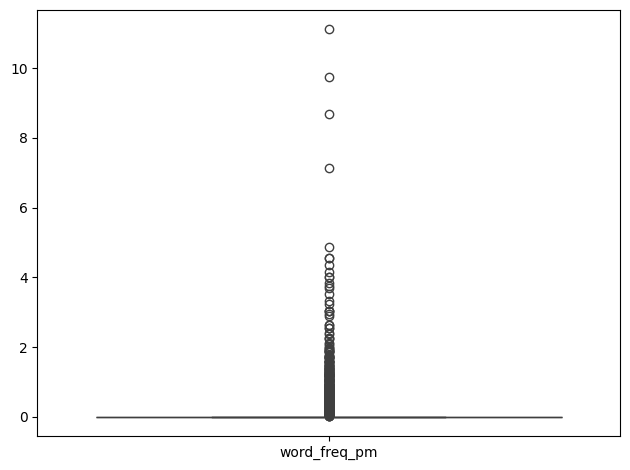

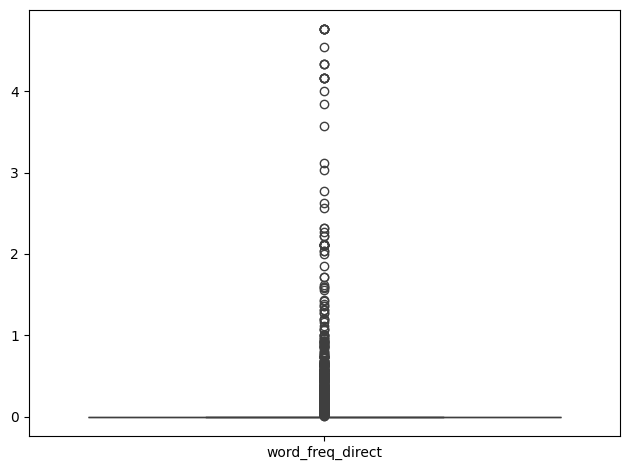

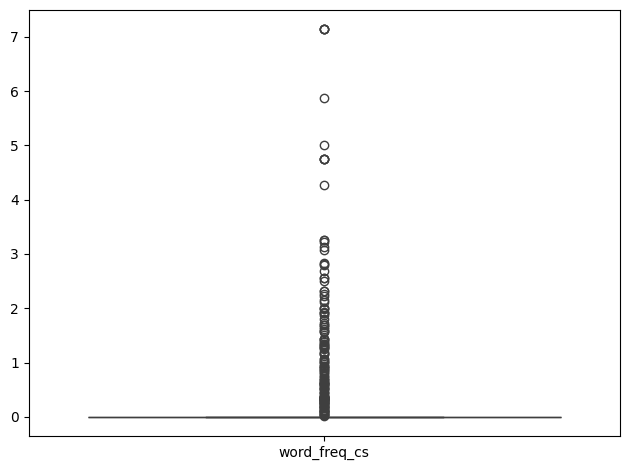

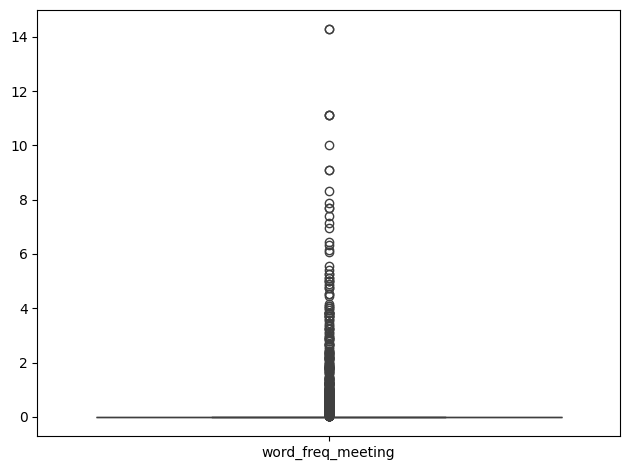

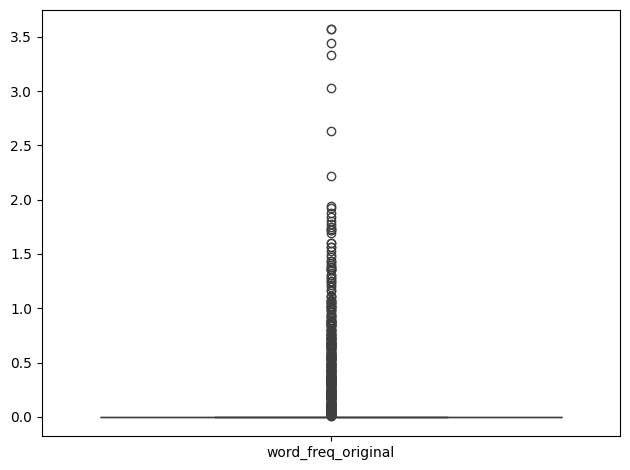

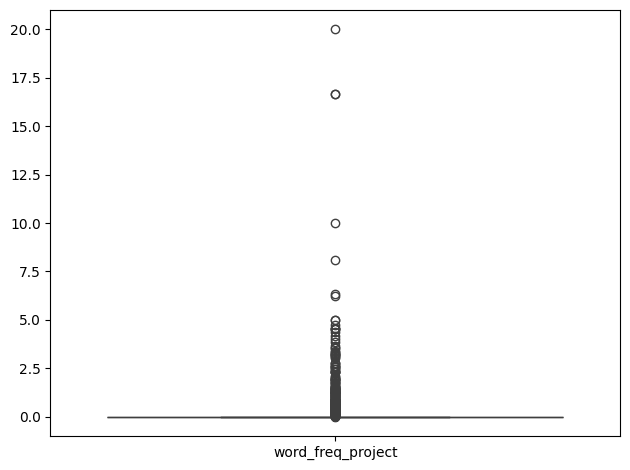

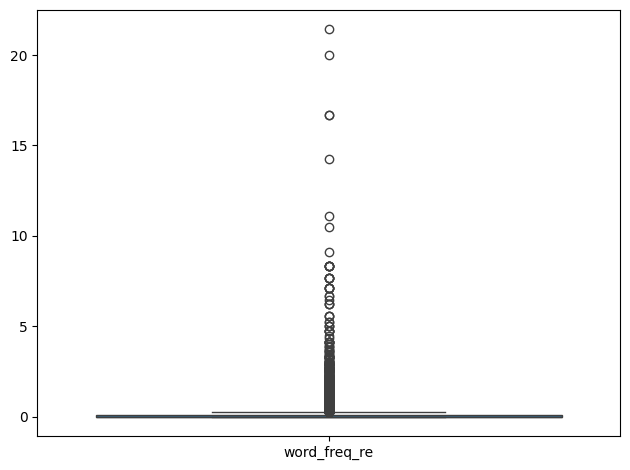

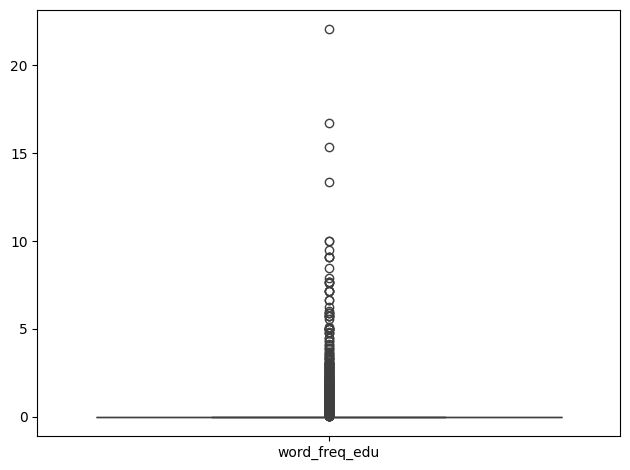

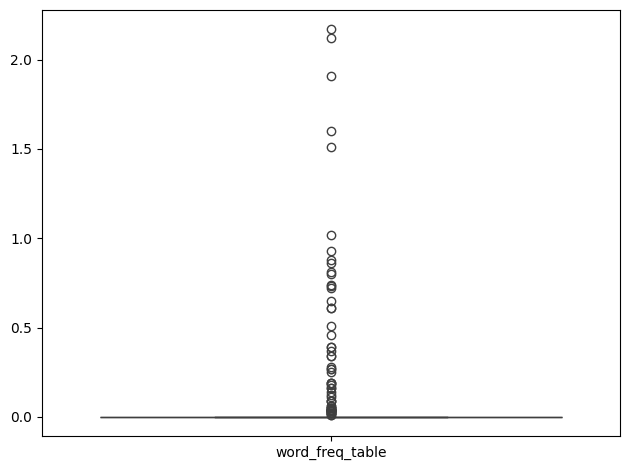

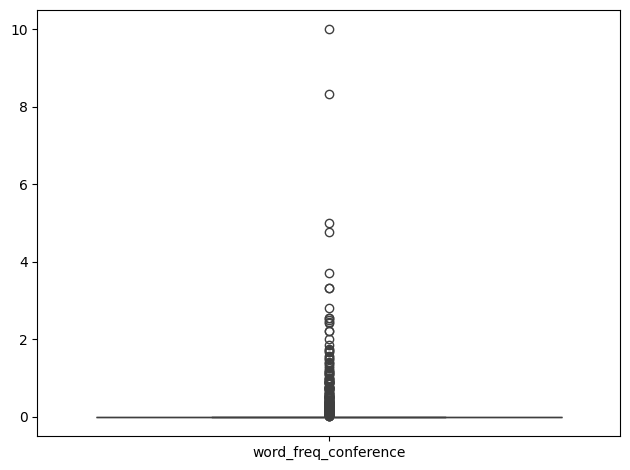

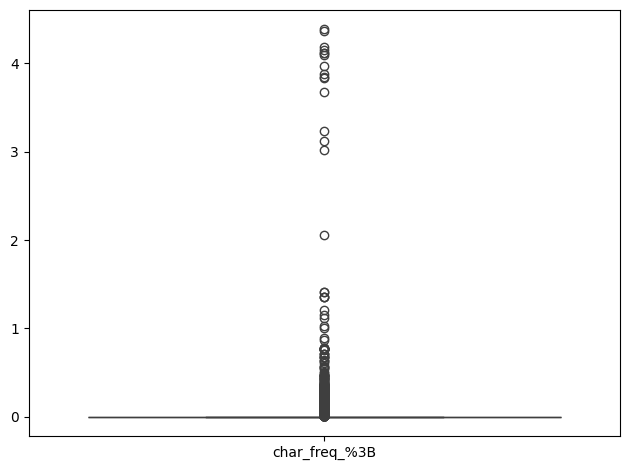

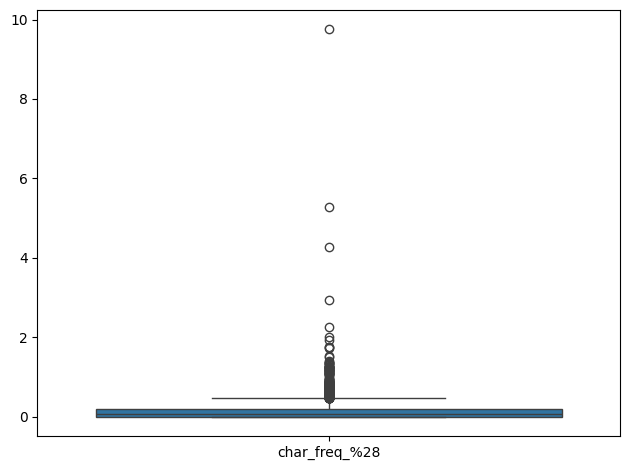

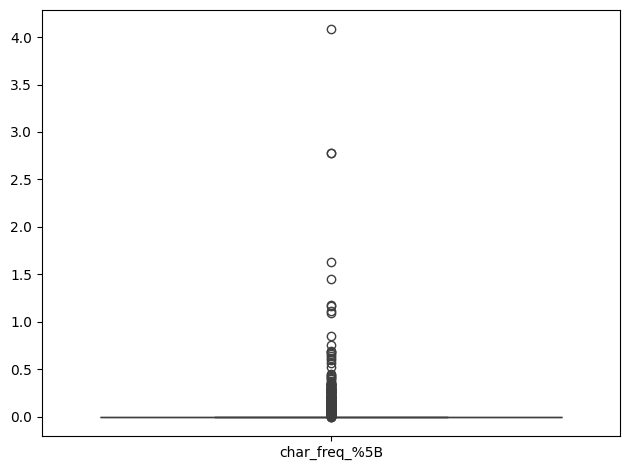

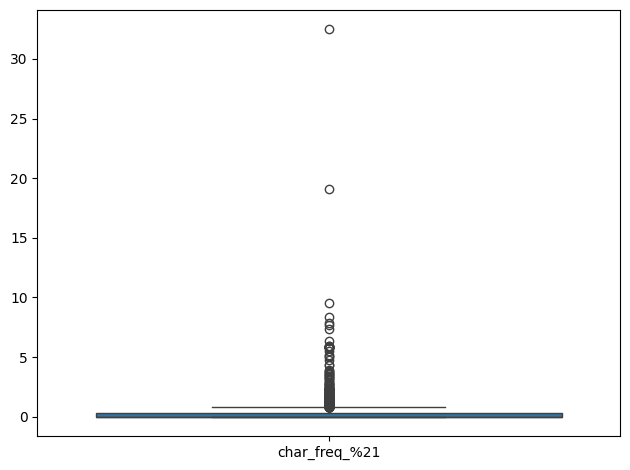

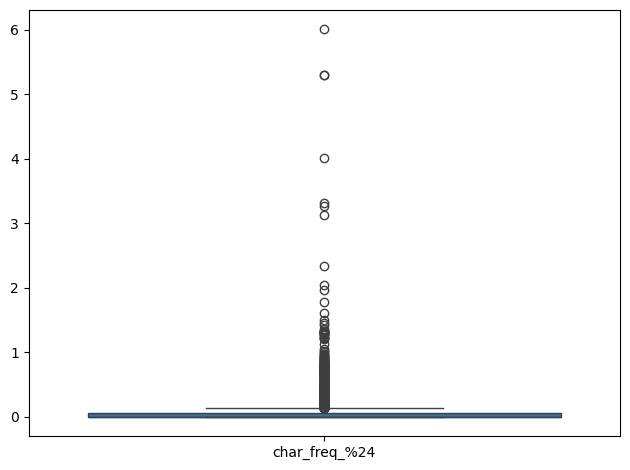

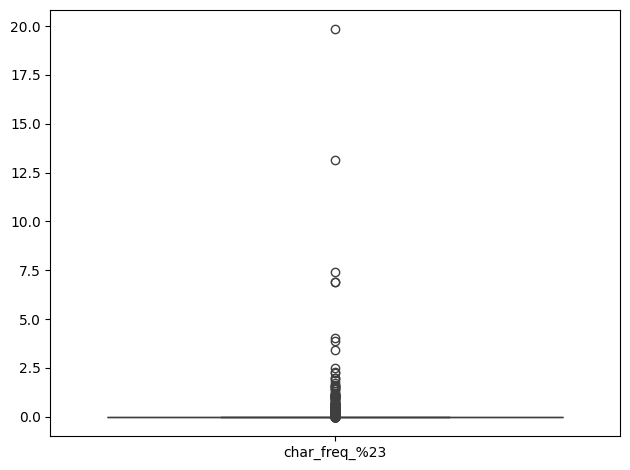

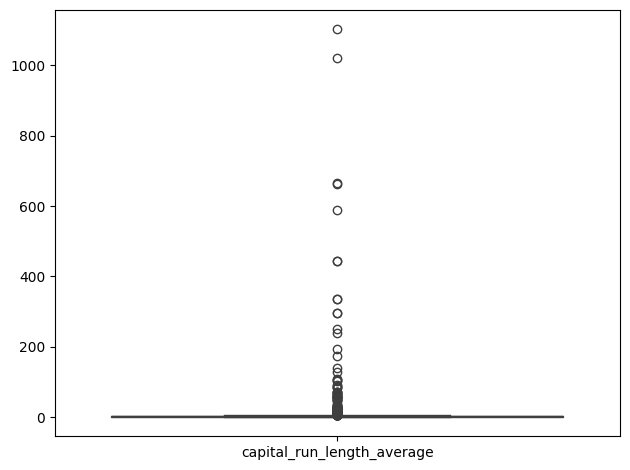

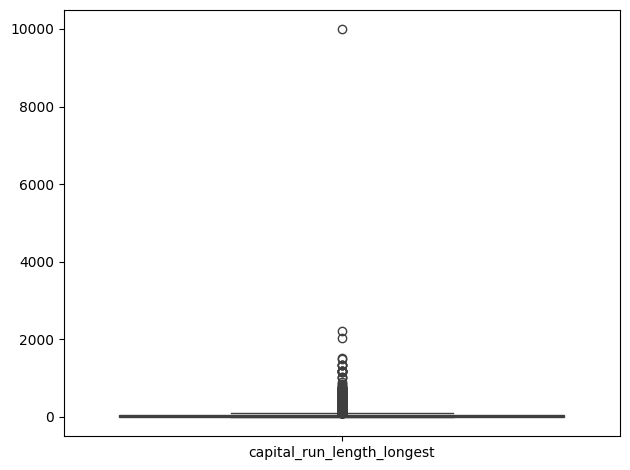

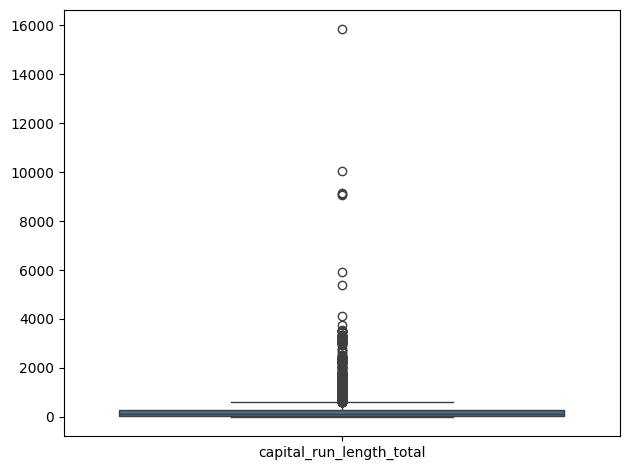

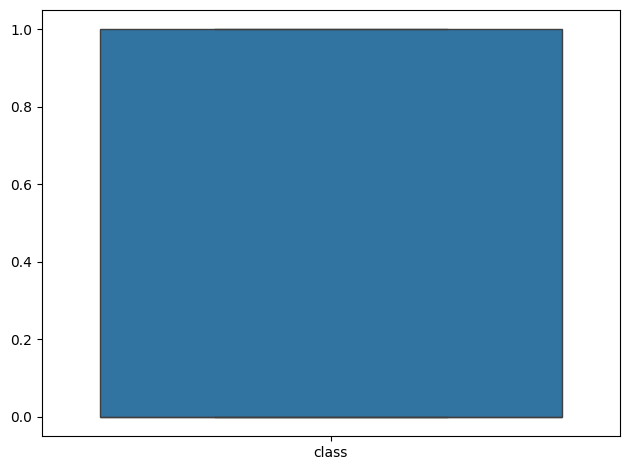

In [ ]:
for col in data.columns:
  sns.boxplot(data[[col]])
  #plt.title(col)
  plt.tight_layout()
  plt.show()


In [ ]:
x = data.iloc[:,:-1]
y = data.iloc[:,-1]

In [ ]:
'''for col in x.columns:
  Q1 = x[col].quantile(0.25)
  Q3 = x[col].quantile(0.75)
  IQR = Q3 - Q1
  low = Q1 - 1.5 * IQR
  high = Q3 + 1.5 * IQR

  x[col] = x[col].clip(low, high)'''

'for col in x.columns:\n  Q1 = x[col].quantile(0.25)\n  Q3 = x[col].quantile(0.75)\n  IQR = Q3 - Q1\n  low = Q1 - 1.5 * IQR\n  high = Q3 + 1.5 * IQR\n\n  x[col] = x[col].clip(low, high)'

In [ ]:
'''for col in x.columns:
  sns.boxplot(col)
  plt.tight_layout()
  plt.show()'''

'for col in x.columns:\n  sns.boxplot(col)\n  plt.tight_layout()\n  plt.show()'

**(iii) Standarization / Normalization**

In [ ]:
x.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191


In [ ]:
x_standard = x
standard = StandardScaler()

for col in x_standard:
  x_standard[col] = standard.fit_transform(x_standard[[col]])

x_standard.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,-0.342434,0.330885,0.712859,-0.0469,0.011565,-0.350266,-0.291794,-0.262562,-0.323302,-0.371364,...,-0.111546,-0.158453,-0.514307,-0.155198,0.624007,-0.308355,-0.103048,-0.045247,0.045298,-0.008724
1,0.345359,0.051909,0.435130,-0.0469,-0.256117,0.672399,0.244743,-0.088010,-0.323302,1.086711,...,-0.111546,-0.158453,-0.026007,-0.155198,0.126203,0.423783,0.008763,-0.002443,0.250563,1.228324
2,-0.145921,-0.165072,0.851723,-0.0469,1.364846,0.343685,0.193644,0.036670,1.974017,0.016422,...,-0.111546,-0.117376,0.014684,-0.155198,0.008496,0.440053,-0.079754,0.145921,2.221106,3.258733
3,-0.342434,-0.165072,-0.556761,-0.0469,0.472573,-0.350266,0.500237,1.308402,0.789462,0.605857,...,-0.111546,-0.158453,-0.007511,-0.155198,-0.161934,-0.308355,-0.103048,-0.052150,-0.062466,-0.152222
4,-0.342434,-0.165072,-0.556761,-0.0469,0.472573,-0.350266,0.500237,1.308402,0.789462,0.605857,...,-0.111546,-0.158453,-0.014910,-0.155198,-0.164387,-0.308355,-0.103048,-0.052150,-0.062466,-0.152222


In [ ]:
x_norm = x
normalize = MinMaxScaler()

for col in x_norm:
  x_norm[col] = normalize.fit_transform(x_norm[[col]])

x_norm.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.000000,0.044818,0.125490,0.0,0.032,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.023955,0.000000,0.000000,0.002502,0.006007,0.017487
1,0.046256,0.019608,0.098039,0.0,0.014,0.047619,0.028886,0.006301,0.000000,0.051705,...,0.0,0.000000,0.013536,0.0,0.011454,0.029985,0.002421,0.003735,0.010012,0.064836
2,0.013216,0.000000,0.139216,0.0,0.123,0.032313,0.026135,0.010801,0.121673,0.013751,...,0.0,0.002281,0.014664,0.0,0.008498,0.030651,0.000504,0.008008,0.048458,0.142551
3,0.000000,0.000000,0.000000,0.0,0.063,0.000000,0.042641,0.056706,0.058935,0.034653,...,0.0,0.000000,0.014048,0.0,0.004218,0.000000,0.000000,0.002303,0.003905,0.011995
4,0.000000,0.000000,0.000000,0.0,0.063,0.000000,0.042641,0.056706,0.058935,0.034653,...,0.0,0.000000,0.013843,0.0,0.004157,0.000000,0.000000,0.002303,0.003905,0.011995


#**Splitting**

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x_norm,y,test_size=0.5)
x_val,x_test,y_val,y_test = train_test_split(x_test,y_test,test_size=0.2)

In [ ]:
print(x_train.shape,y_train.shape)

(3680, 57) (3680,)


In [ ]:
print(x_val.shape,y_val.shape)
print(x_test.shape,y_test.shape)

(1840, 57) (1840,)
(920, 57) (920,)


#**Model Building**

#**(i) Bernoulli NB**

Accuracy Score of Training  : 0.8858695652173914
Precision Score of Training : 0.8762190547636909
F1 Score of Training        : 0.8476052249637155
Recall Score of Training    : 0.8208011243851019

Confusion Matrix :- 
 [[2092  165]
 [ 255 1168]]

Accuracy Score of Testing  : 0.8805646036916395
Precision Score of Testing : 0.9046242774566474
F1 Score of Testing        : 0.8505434782608695
Recall Score of Testing    : 0.8025641025641026

Confusion Matrix :- 
 [[2092  165]
 [ 255 1168]]


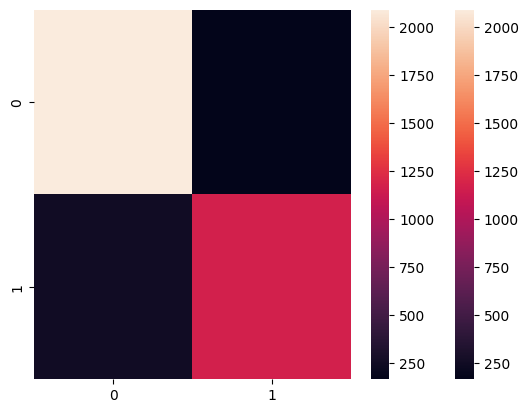

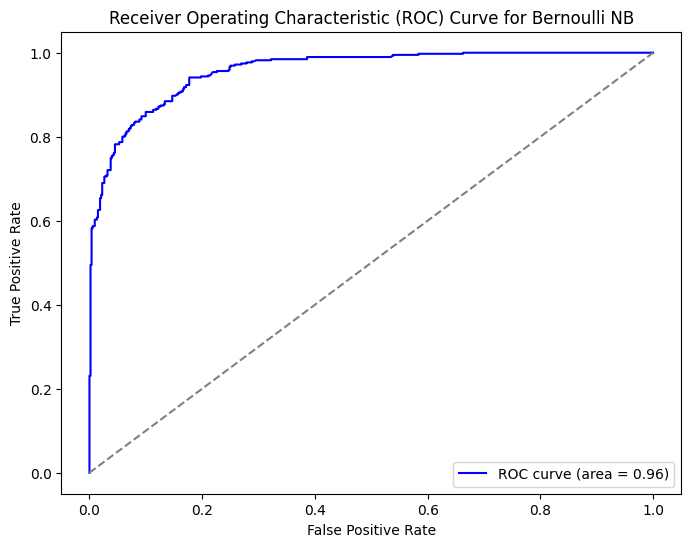

In [ ]:
model = BernoulliNB()
model.fit(x_train,y_train)
y_pre_train = model.predict(x_train)
con_train_model = confusion_matrix(y_train,y_pre_train)
sns.heatmap(con_train_model)

accuracy_model_train = accuracy_score(y_train,y_pre_train)
precision_model_train = precision_score(y_train,y_pre_train)
f1_model_train = f1_score(y_train,y_pre_train)
recall_model_train = recall_score(y_train,y_pre_train)

print("Accuracy Score of Training  :",accuracy_model_train)
print("Precision Score of Training :",precision_model_train)
print("F1 Score of Training        :",f1_model_train)
print("Recall Score of Training    :",recall_model_train)
print("\nConfusion Matrix :- \n",con_train_model)

y_pre_test = model.predict(x_test)
con_test_model = confusion_matrix(y_train,y_pre_train)
sns.heatmap(con_test_model)

accuracy_model_test = accuracy_score(y_test,y_pre_test)
precision_model_test = precision_score(y_test,y_pre_test)
f1_model_test = f1_score(y_test,y_pre_test)
recall_model_test = recall_score(y_test,y_pre_test)

print("\nAccuracy Score of Testing  :",accuracy_model_test)
print("Precision Score of Testing :",precision_model_test)
print("F1 Score of Testing        :",f1_model_test)
print("Recall Score of Testing    :",recall_model_test)
print("\nConfusion Matrix :- \n",con_test_model)

y_probs_knn = model.predict_proba(x_test)[:, 1]

# Calculate FPR and TPR for different thresholds
fpr_model, tpr_model, thresholds = roc_curve(y_test, y_probs_knn)

# Calculate the AUC
roc_auc_model = auc(fpr_model, tpr_model)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_model, tpr_model, color='b', label=f'ROC curve (area = {roc_auc_model:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curve for Bernoulli NB')
plt.legend(loc='lower right')
plt.show()

In [ ]:
model.get_params()

{'alpha': 1.0,
 'binarize': 0.0,
 'class_prior': None,
 'fit_prior': True,
 'force_alpha': True}

#**(ii) Gaussian NB**

Accuracy Score of Training  : 0.8082608695652174
Precision Score of Training : 0.6844135802469136
F1 Score of Training        : 0.800902934537246
Recall Score of Training    : 0.9651795429815017

Confusion Matrix :- 
 [[972 409]
 [ 32 887]]

Accuracy Score of Testing  : 0.8004338394793926
Precision Score of Testing : 0.6612244897959184
F1 Score of Testing        : 0.7788461538461539
Recall Score of Testing    : 0.9473684210526315

Confusion Matrix :- 
 [[972 409]
 [ 32 887]]


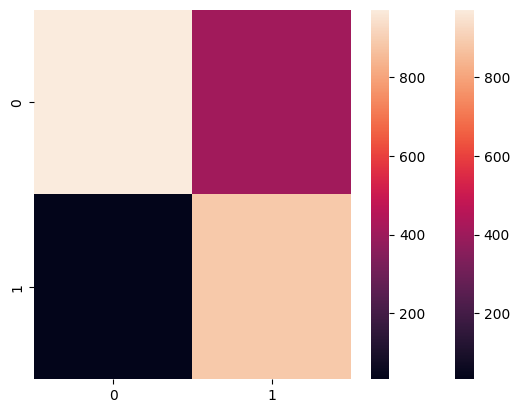

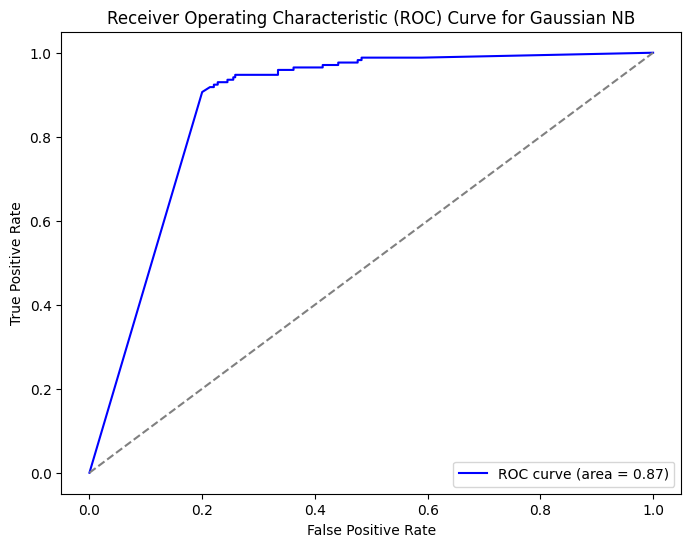

In [ ]:
model = GaussianNB()
model.fit(x_train,y_train)
y_pre_train = model.predict(x_train)
con_train_model = confusion_matrix(y_train,y_pre_train)
sns.heatmap(con_train_model)

accuracy_model_train = accuracy_score(y_train,y_pre_train)
precision_model_train = precision_score(y_train,y_pre_train)
f1_model_train = f1_score(y_train,y_pre_train)
recall_model_train = recall_score(y_train,y_pre_train)

print("Accuracy Score of Training  :",accuracy_model_train)
print("Precision Score of Training :",precision_model_train)
print("F1 Score of Training        :",f1_model_train)
print("Recall Score of Training    :",recall_model_train)
print("\nConfusion Matrix :- \n",con_train_model)

y_pre_test = model.predict(x_test)
con_test_model = confusion_matrix(y_train,y_pre_train)
sns.heatmap(con_test_model)

accuracy_model_test = accuracy_score(y_test,y_pre_test)
precision_model_test = precision_score(y_test,y_pre_test)
f1_model_test = f1_score(y_test,y_pre_test)
recall_model_test = recall_score(y_test,y_pre_test)

print("\nAccuracy Score of Testing  :",accuracy_model_test)
print("Precision Score of Testing :",precision_model_test)
print("F1 Score of Testing        :",f1_model_test)
print("Recall Score of Testing    :",recall_model_test)
print("\nConfusion Matrix :- \n",con_test_model)

y_probs_knn = model.predict_proba(x_test)[:, 1]

# Calculate FPR and TPR for different thresholds
fpr_model, tpr_model, thresholds = roc_curve(y_test, y_probs_knn)

# Calculate the AUC
roc_auc_model = auc(fpr_model, tpr_model)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_model, tpr_model, color='b', label=f'ROC curve (area = {roc_auc_model:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curve for Gaussian NB')
plt.legend(loc='lower right')
plt.show()

In [ ]:
model.get_params()

{'priors': None, 'var_smoothing': 1e-09}

#**(iii) Multinomial NB**

Accuracy Score of Training  : 0.89
Precision Score of Training : 0.9428191489361702
F1 Score of Training        : 0.8485936564931179
Recall Score of Training    : 0.7714907508161044

Confusion Matrix :- 
 [[1338   43]
 [ 210  709]]

Accuracy Score of Testing  : 0.8937093275488069
Precision Score of Testing : 0.8961038961038961
F1 Score of Testing        : 0.8492307692307692
Recall Score of Testing    : 0.8070175438596491

Confusion Matrix :- 
 [[1338   43]
 [ 210  709]]


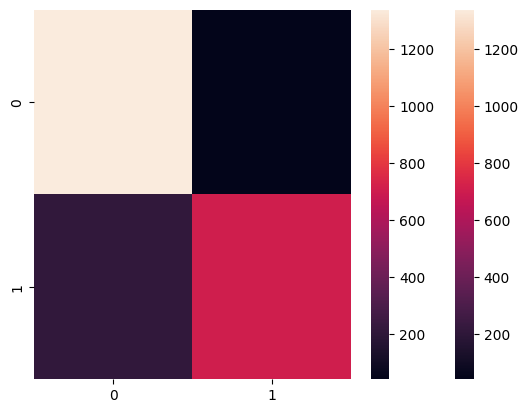

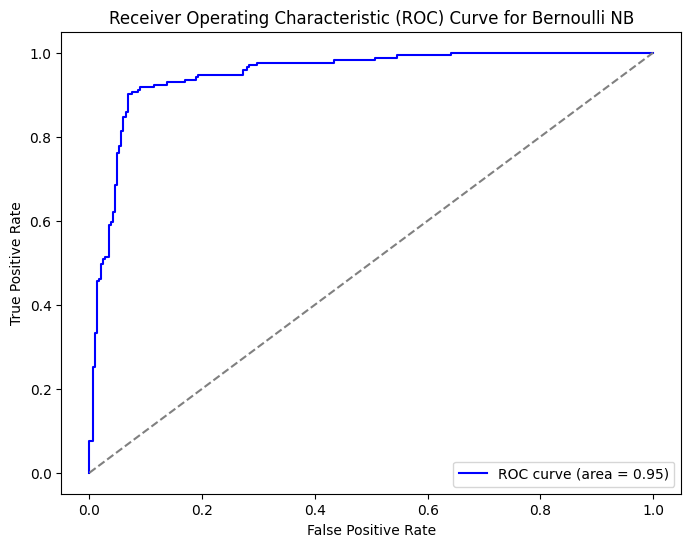

In [ ]:
model = MultinomialNB()
model.fit(x_train,y_train)
y_pre_train = model.predict(x_train)
con_train_model = confusion_matrix(y_train,y_pre_train)
sns.heatmap(con_train_model)

accuracy_model_train = accuracy_score(y_train,y_pre_train)
precision_model_train = precision_score(y_train,y_pre_train)
f1_model_train = f1_score(y_train,y_pre_train)
recall_model_train = recall_score(y_train,y_pre_train)

print("Accuracy Score of Training  :",accuracy_model_train)
print("Precision Score of Training :",precision_model_train)
print("F1 Score of Training        :",f1_model_train)
print("Recall Score of Training    :",recall_model_train)
print("\nConfusion Matrix :- \n",con_train_model)

y_pre_test = model.predict(x_test)
con_test_model = confusion_matrix(y_train,y_pre_train)
sns.heatmap(con_test_model)

accuracy_model_test = accuracy_score(y_test,y_pre_test)
precision_model_test = precision_score(y_test,y_pre_test)
f1_model_test = f1_score(y_test,y_pre_test)
recall_model_test = recall_score(y_test,y_pre_test)

print("\nAccuracy Score of Testing  :",accuracy_model_test)
print("Precision Score of Testing :",precision_model_test)
print("F1 Score of Testing        :",f1_model_test)
print("Recall Score of Testing    :",recall_model_test)
print("\nConfusion Matrix :- \n",con_test_model)

y_probs_knn = model.predict_proba(x_test)[:, 1]

# Calculate FPR and TPR for different thresholds
fpr_model, tpr_model, thresholds = roc_curve(y_test, y_probs_knn)

# Calculate the AUC
roc_auc_model = auc(fpr_model, tpr_model)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_model, tpr_model, color='b', label=f'ROC curve (area = {roc_auc_model:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curve for Bernoulli NB')
plt.legend(loc='lower right')
plt.show()

#**Cross validation**

**(i) Bernoulli NB**


----- Fold ------
Accuracy Score of Training  : 0.8858695652173914
Precision Score of Training : 0.8762190547636909
F1 Score of Training        : 0.8476052249637155
Recall Score of Training    : 0.8208011243851019

Confusion Matrix :- 
 [[2092  165]
 [ 255 1168]]

Accuracy Score of Testing  : 0.8805646036916395
Precision Score of Testing : 0.9046242774566474
F1 Score of Testing        : 0.8505434782608695
Recall Score of Testing    : 0.8025641025641026

Confusion Matrix :- 
 [[2092  165]
 [ 255 1168]]


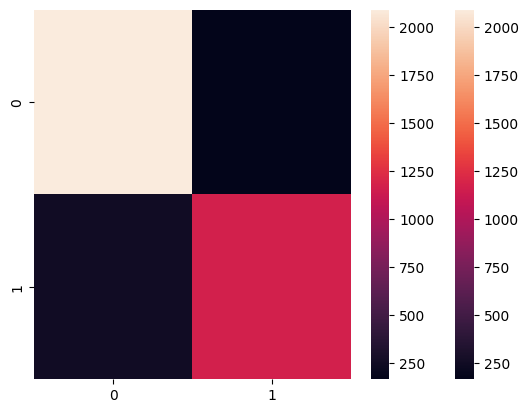

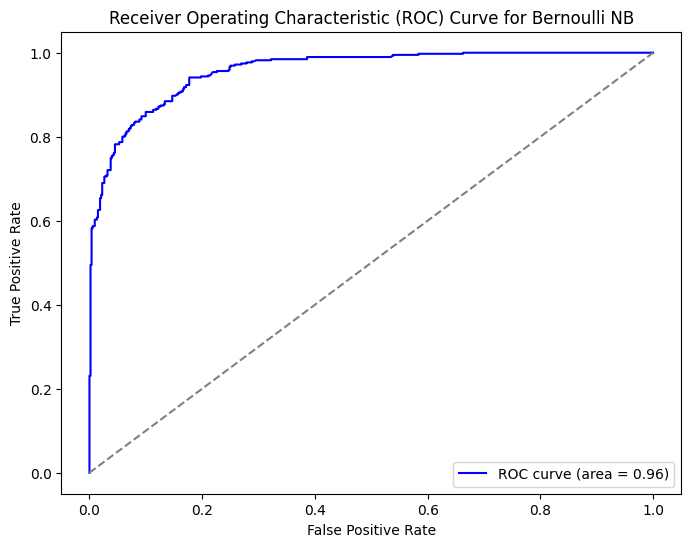


----- Fold ------
Accuracy Score of Training  : 0.8883455582722086
Precision Score of Training : 0.8892215568862275
F1 Score of Training        : 0.852529601722282
Recall Score of Training    : 0.8187456926257753

Confusion Matrix :- 
 [[2082  148]
 [ 263 1188]]

Accuracy Score of Testing  : 0.8934782608695652
Precision Score of Testing : 0.875
F1 Score of Testing        : 0.8627450980392157
Recall Score of Testing    : 0.850828729281768

Confusion Matrix :- 
 [[2082  148]
 [ 263 1188]]


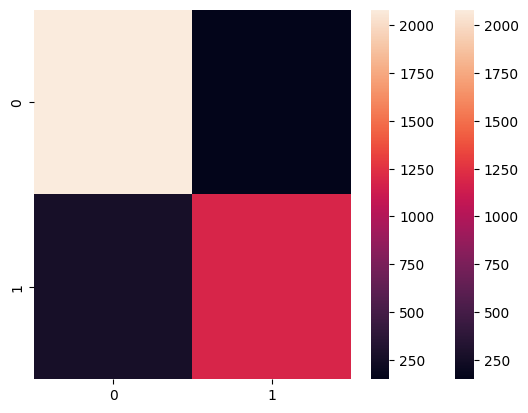

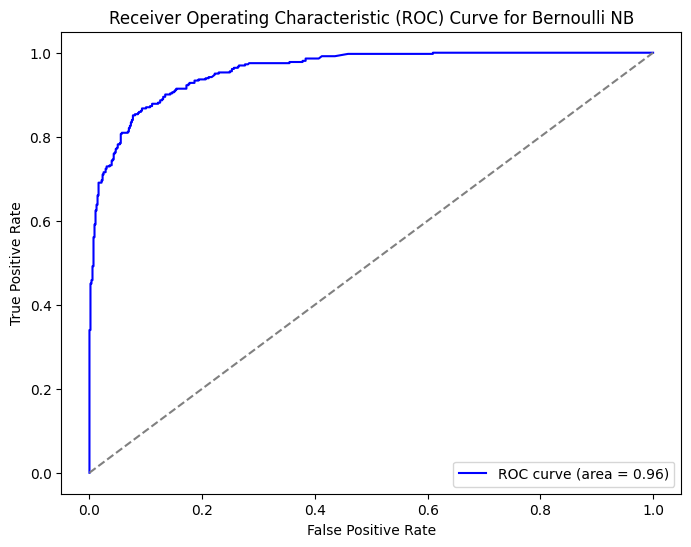


----- Fold ------
Accuracy Score of Training  : 0.8888888888888888
Precision Score of Training : 0.890625
F1 Score of Training        : 0.8540849090260435
Recall Score of Training    : 0.820424948594928

Confusion Matrix :- 
 [[2075  147]
 [ 262 1197]]

Accuracy Score of Testing  : 0.8891304347826087
Precision Score of Testing : 0.8579545454545454
F1 Score of Testing        : 0.8555240793201133
Recall Score of Testing    : 0.8531073446327684

Confusion Matrix :- 
 [[2075  147]
 [ 262 1197]]


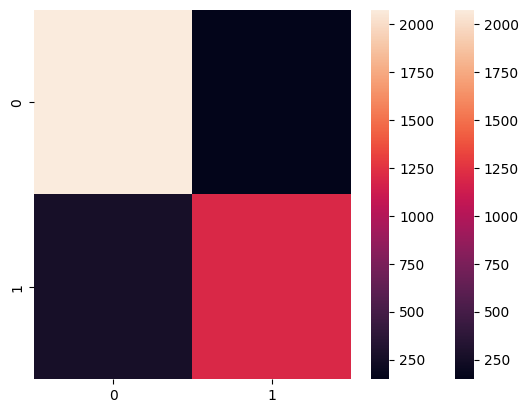

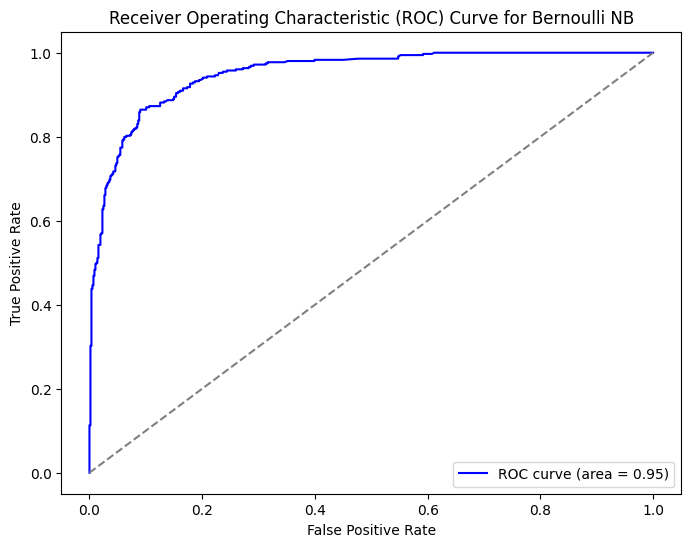


----- Fold ------
Accuracy Score of Training  : 0.8891605541972291
Precision Score of Training : 0.8860482103725347
F1 Score of Training        : 0.8560338743824982
Recall Score of Training    : 0.8279863481228669

Confusion Matrix :- 
 [[2060  156]
 [ 252 1213]]

Accuracy Score of Testing  : 0.8869565217391304
Precision Score of Testing : 0.8788819875776398
F1 Score of Testing        : 0.844776119402985
Recall Score of Testing    : 0.8132183908045977

Confusion Matrix :- 
 [[2060  156]
 [ 252 1213]]


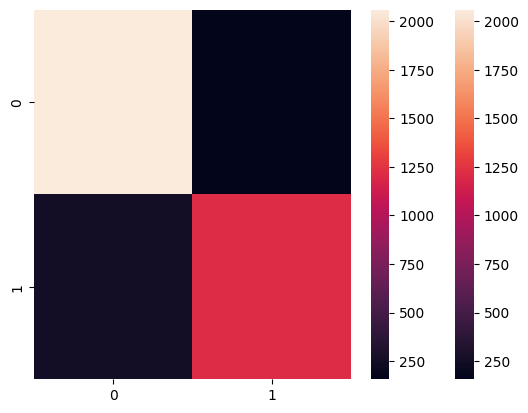

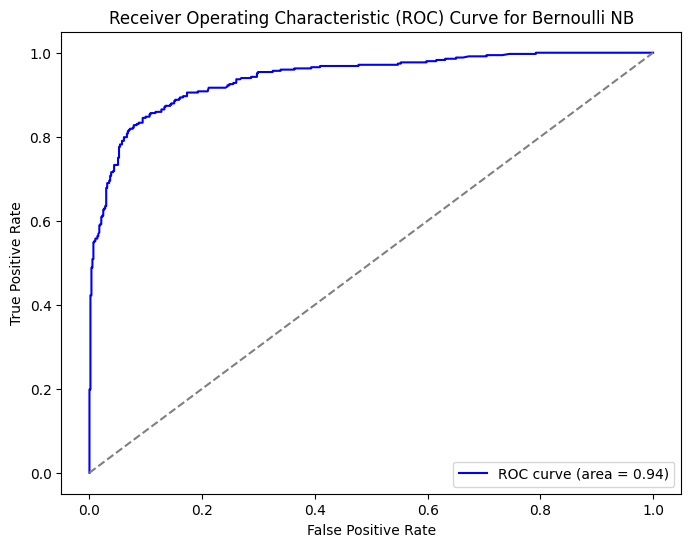


----- Fold ------
Accuracy Score of Training  : 0.8888888888888888
Precision Score of Training : 0.8827838827838828
F1 Score of Training        : 0.8549130897481376
Recall Score of Training    : 0.828748280605227

Confusion Matrix :- 
 [[2067  160]
 [ 249 1205]]

Accuracy Score of Testing  : 0.8902173913043478
Precision Score of Testing : 0.9056603773584906
F1 Score of Testing        : 0.8508124076809453
Recall Score of Testing    : 0.8022284122562674

Confusion Matrix :- 
 [[2067  160]
 [ 249 1205]]


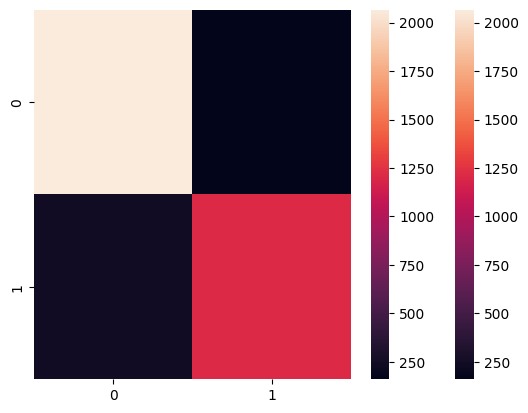

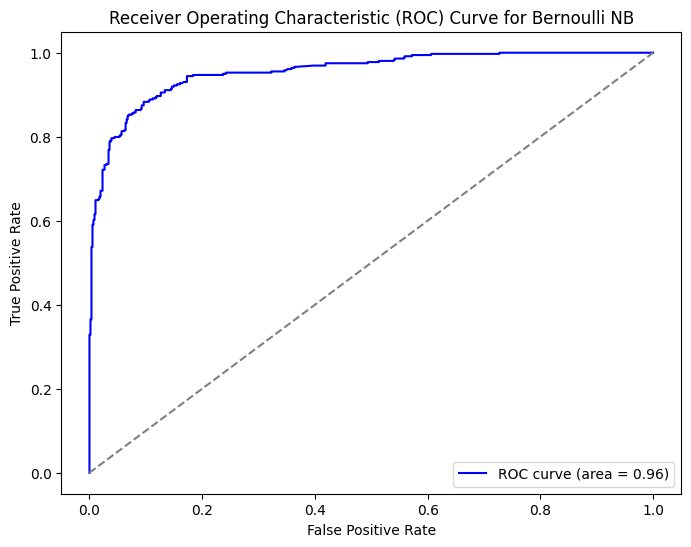

In [ ]:
accuracy = []
precision = []
f1 = []
recall = []
area = []

model = BernoulliNB()
kf = KFold(n_splits=5,shuffle=True,random_state=42)

for train_index,test_index in kf.split(x):

  x_train,x_test = x_norm.iloc[train_index],x_norm.iloc[test_index]
  y_train,y_test = y.iloc[train_index],y.iloc[test_index]

  print("\n----- Fold ------")

  model.fit(x_train,y_train)
  y_pre_train = model.predict(x_train)
  con_train_model = confusion_matrix(y_train,y_pre_train)
  sns.heatmap(con_train_model)

  accuracy_model_train = accuracy_score(y_train,y_pre_train)
  precision_model_train = precision_score(y_train,y_pre_train)
  f1_model_train = f1_score(y_train,y_pre_train)
  recall_model_train = recall_score(y_train,y_pre_train)

  print("Accuracy Score of Training  :",accuracy_model_train)
  print("Precision Score of Training :",precision_model_train)
  print("F1 Score of Training        :",f1_model_train)
  print("Recall Score of Training    :",recall_model_train)
  print("\nConfusion Matrix :- \n",con_train_model)

  y_pre_test = model.predict(x_test)
  con_test_model = confusion_matrix(y_train,y_pre_train)
  sns.heatmap(con_test_model)

  accuracy_model_test = accuracy_score(y_test,y_pre_test)
  precision_model_test = precision_score(y_test,y_pre_test)
  f1_model_test = f1_score(y_test,y_pre_test)
  recall_model_test = recall_score(y_test,y_pre_test)

  accuracy.append(accuracy_model_test)
  precision.append(precision_model_test)
  f1.append(f1_model_test)
  recall.append(recall_model_test)

  print("\nAccuracy Score of Testing  :",accuracy_model_test)
  print("Precision Score of Testing :",precision_model_test)
  print("F1 Score of Testing        :",f1_model_test)
  print("Recall Score of Testing    :",recall_model_test)
  print("\nConfusion Matrix :- \n",con_test_model)

  y_probs_model = model.predict_proba(x_test)[:, 1]

  # Calculate FPR and TPR for different thresholds
  fpr_model, tpr_model, thresholds = roc_curve(y_test, y_probs_model)

  # Calculate the AUC
  roc_auc_model = auc(fpr_model, tpr_model)

  area.append(roc_auc_model)

  # Plot the ROC curve
  plt.figure(figsize=(8, 6))
  plt.plot(fpr_model, tpr_model, color='b', label=f'ROC curve (area = {roc_auc_model:.2f})')
  plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for Bernoulli NB')
  plt.legend(loc='lower right')
  plt.show()

In [ ]:
df = pd.DataFrame({
    'KFold': list(range(1, 6)),
    'accuracy': accuracy,
    'precision': precision,
    'f1': f1,
    'recall': recall,
    'auc': area
})

mean_row = pd.DataFrame([{
    'KFold': 'Mean',
    'accuracy': np.mean(accuracy),
    'precision': np.mean(precision),
    'f1': np.mean(f1),
    'recall': np.mean(recall),
    'auc': np.mean(area)
}])

df = pd.concat([df, mean_row], ignore_index=True)


print("K Fold for Bernoulli NB :-\n")
df

K Fold for Bernoulli NB :-



,KFold,accuracy,precision,f1,recall,auc
0,1,0.880565,0.904624,0.850543,0.802564,0.956903
1,2,0.893478,0.875000,0.862745,0.850829,0.958120
2,3,0.889130,0.857955,0.855524,0.853107,0.950755
3,4,0.886957,0.878882,0.844776,0.813218,0.940549
4,5,0.890217,0.905660,0.850812,0.802228,0.955102
5,Mean,0.888069,0.884424,0.852880,0.824389,0.952286


**(ii) Gaussian NB**


----- Fold ------
Accuracy Score of Training  : 0.8206521739130435
Precision Score of Training : 0.6951406649616368
F1 Score of Training        : 0.8046181172291297
Recall Score of Training    : 0.955024595924104

Confusion Matrix :- 
 [[1661  596]
 [  64 1359]]

Accuracy Score of Testing  : 0.8219326818675353
Precision Score of Testing : 0.7233201581027668
F1 Score of Testing        : 0.8169642857142857
Recall Score of Testing    : 0.9384615384615385

Confusion Matrix :- 
 [[1661  596]
 [  64 1359]]


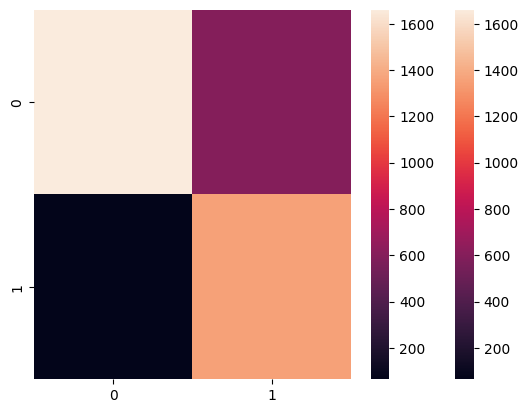

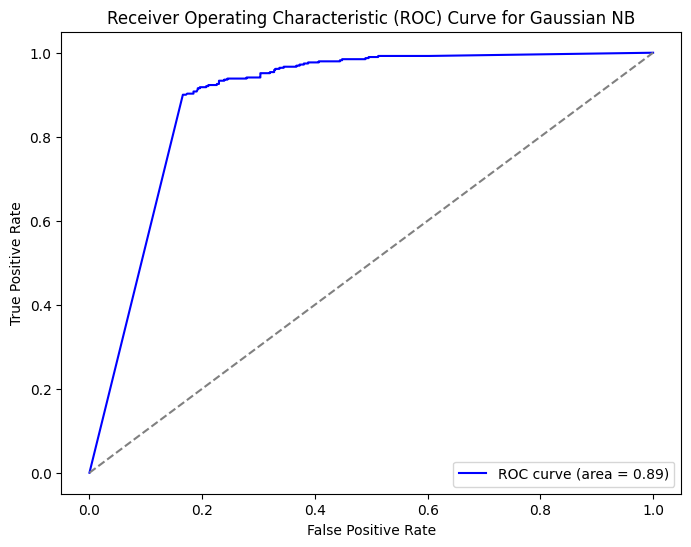


----- Fold ------
Accuracy Score of Training  : 0.8063026351534909
Precision Score of Training : 0.6815944881889764
F1 Score of Training        : 0.7952914154464542
Recall Score of Training    : 0.954514128187457

Confusion Matrix :- 
 [[1583  647]
 [  66 1385]]

Accuracy Score of Testing  : 0.8065217391304348
Precision Score of Testing : 0.6762452107279694
F1 Score of Testing        : 0.7986425339366516
Recall Score of Testing    : 0.9751381215469613

Confusion Matrix :- 
 [[1583  647]
 [  66 1385]]


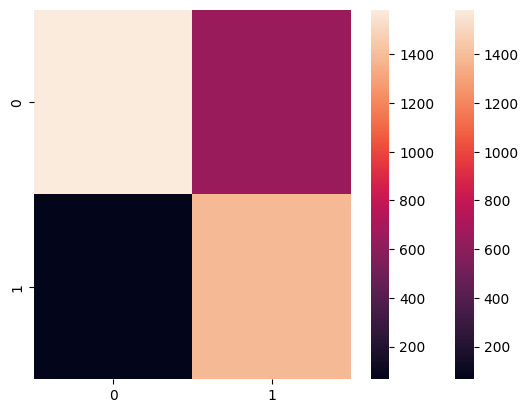

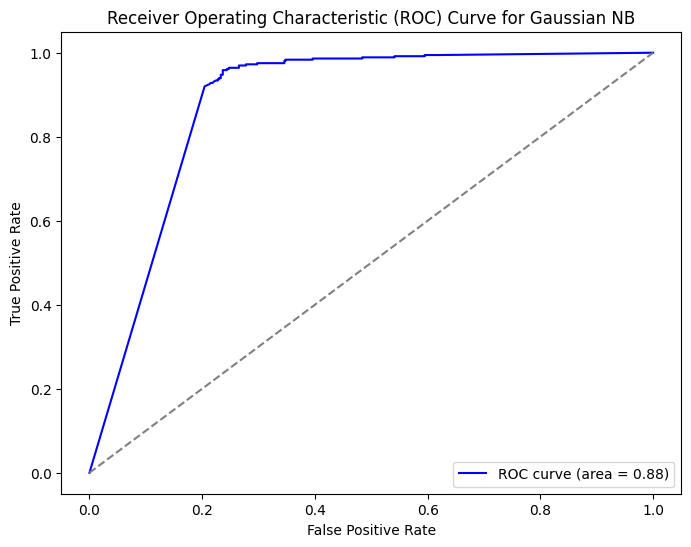


----- Fold ------
Accuracy Score of Training  : 0.8245042108122793
Precision Score of Training : 0.7049924357034796
F1 Score of Training        : 0.8123184195235328
Recall Score of Training    : 0.9581905414667581

Confusion Matrix :- 
 [[1637  585]
 [  61 1398]]

Accuracy Score of Testing  : 0.7945652173913044
Precision Score of Testing : 0.6589595375722543
F1 Score of Testing        : 0.7835051546391752
Recall Score of Testing    : 0.9661016949152542

Confusion Matrix :- 
 [[1637  585]
 [  61 1398]]


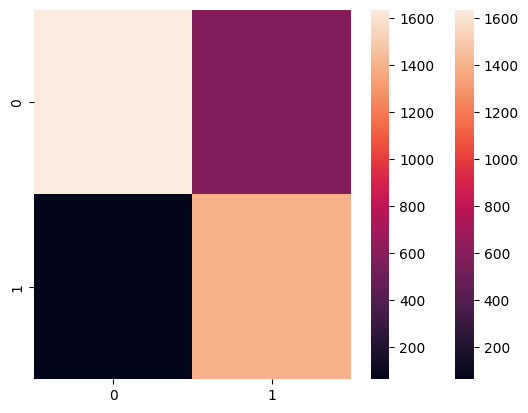

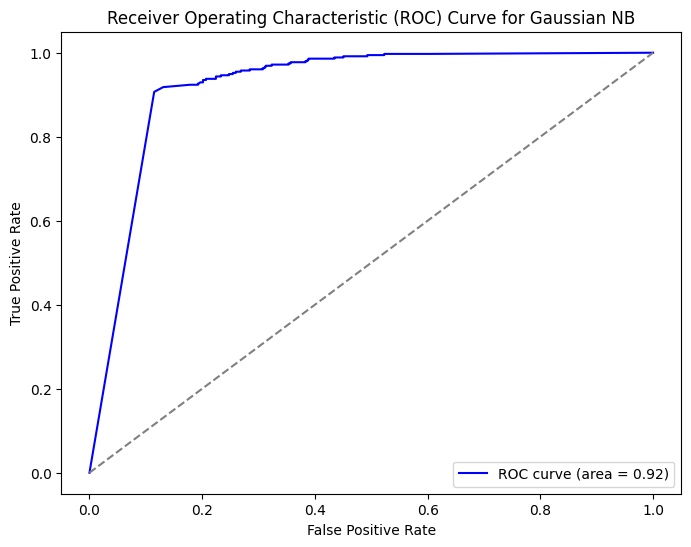


----- Fold ------
Accuracy Score of Training  : 0.8250475414289595
Precision Score of Training : 0.7070095814422592
F1 Score of Training        : 0.8132250580046404
Recall Score of Training    : 0.9569965870307168

Confusion Matrix :- 
 [[1635  581]
 [  63 1402]]

Accuracy Score of Testing  : 0.8228260869565217
Precision Score of Testing : 0.6907216494845361
F1 Score of Testing        : 0.8043217286914766
Recall Score of Testing    : 0.9626436781609196

Confusion Matrix :- 
 [[1635  581]
 [  63 1402]]


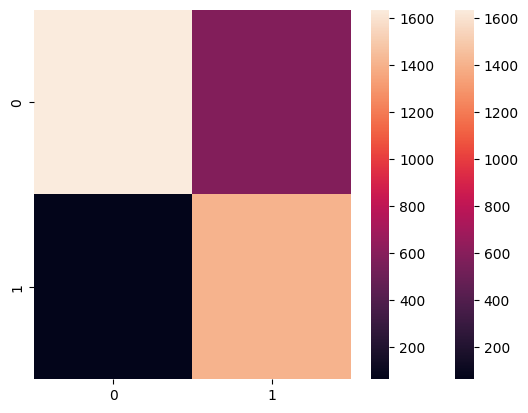

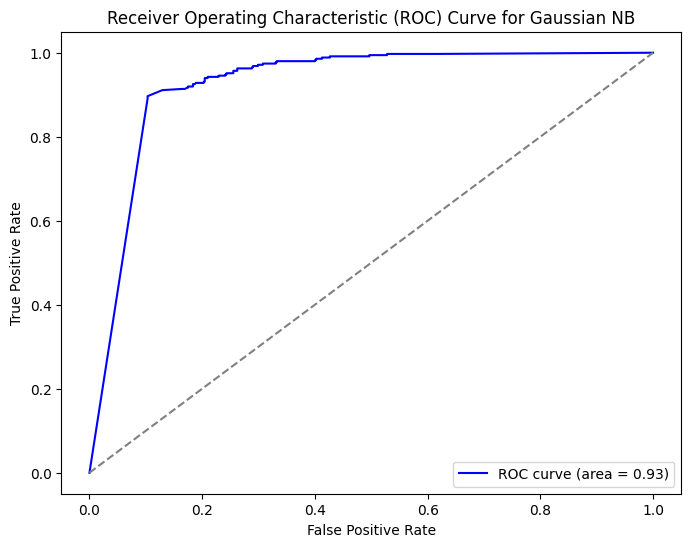


----- Fold ------
Accuracy Score of Training  : 0.8212442271121978
Precision Score of Training : 0.6986027944111777
F1 Score of Training        : 0.8097165991902834
Recall Score of Training    : 0.9628610729023384

Confusion Matrix :- 
 [[1623  604]
 [  54 1400]]

Accuracy Score of Testing  : 0.8336956521739131
Precision Score of Testing : 0.721030042918455
F1 Score of Testing        : 0.8145454545454546
Recall Score of Testing    : 0.935933147632312

Confusion Matrix :- 
 [[1623  604]
 [  54 1400]]


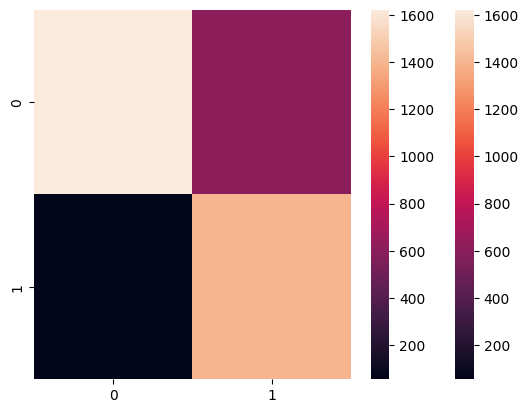

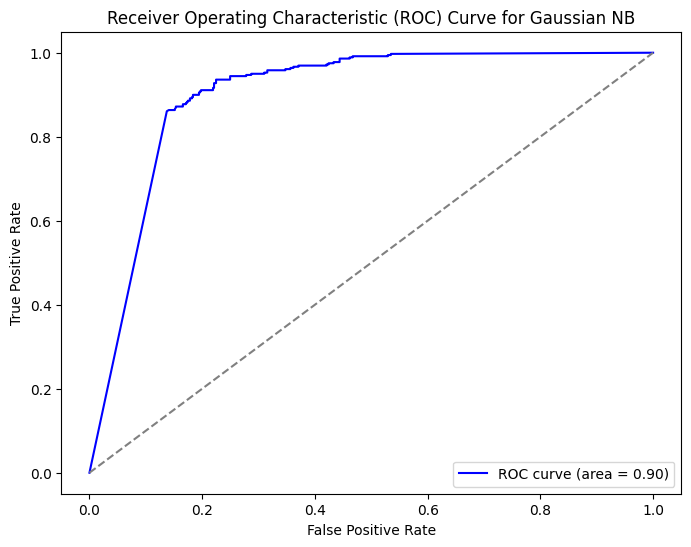

In [ ]:
accuracy = []
precision = []
f1 = []
recall = []
area = []

model = GaussianNB()
kf = KFold(n_splits=5,shuffle=True,random_state=42)

for train_index,test_index in kf.split(x):

  x_train,x_test = x_norm.iloc[train_index],x_norm.iloc[test_index]
  y_train,y_test = y.iloc[train_index],y.iloc[test_index]

  print("\n----- Fold ------")

  model.fit(x_train,y_train)
  y_pre_train = model.predict(x_train)
  con_train_model = confusion_matrix(y_train,y_pre_train)
  sns.heatmap(con_train_model)

  accuracy_model_train = accuracy_score(y_train,y_pre_train)
  precision_model_train = precision_score(y_train,y_pre_train)
  f1_model_train = f1_score(y_train,y_pre_train)
  recall_model_train = recall_score(y_train,y_pre_train)

  print("Accuracy Score of Training  :",accuracy_model_train)
  print("Precision Score of Training :",precision_model_train)
  print("F1 Score of Training        :",f1_model_train)
  print("Recall Score of Training    :",recall_model_train)
  print("\nConfusion Matrix :- \n",con_train_model)

  y_pre_test = model.predict(x_test)
  con_test_model = confusion_matrix(y_train,y_pre_train)
  sns.heatmap(con_test_model)

  accuracy_model_test = accuracy_score(y_test,y_pre_test)
  precision_model_test = precision_score(y_test,y_pre_test)
  f1_model_test = f1_score(y_test,y_pre_test)
  recall_model_test = recall_score(y_test,y_pre_test)

  accuracy.append(accuracy_model_test)
  precision.append(precision_model_test)
  f1.append(f1_model_test)
  recall.append(recall_model_test)

  print("\nAccuracy Score of Testing  :",accuracy_model_test)
  print("Precision Score of Testing :",precision_model_test)
  print("F1 Score of Testing        :",f1_model_test)
  print("Recall Score of Testing    :",recall_model_test)
  print("\nConfusion Matrix :- \n",con_test_model)

  y_probs_model = model.predict_proba(x_test)[:, 1]

  # Calculate FPR and TPR for different thresholds
  fpr_model, tpr_model, thresholds = roc_curve(y_test, y_probs_model)

  # Calculate the AUC
  roc_auc_model = auc(fpr_model, tpr_model)

  area.append(roc_auc_model)

  # Plot the ROC curve
  plt.figure(figsize=(8, 6))
  plt.plot(fpr_model, tpr_model, color='b', label=f'ROC curve (area = {roc_auc_model:.2f})')
  plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for Gaussian NB')
  plt.legend(loc='lower right')
  plt.show()

In [ ]:
df = pd.DataFrame({
    'KFold': list(range(1, 6)),
    'accuracy': accuracy,
    'precision': precision,
    'f1': f1,
    'recall': recall,
    'auc': area
})

mean_row = pd.DataFrame([{
    'KFold': 'Mean',
    'accuracy': np.mean(accuracy),
    'precision': np.mean(precision),
    'f1': np.mean(f1),
    'recall': np.mean(recall),
    'auc': np.mean(area)
}])

df = pd.concat([df, mean_row], ignore_index=True)


print("K Fold for Gaussian NB :-\n")
df

K Fold for Gaussian NB :-



,KFold,accuracy,precision,f1,recall,auc
0,1,0.821933,0.723320,0.816964,0.938462,0.891279
1,2,0.806522,0.676245,0.798643,0.975138,0.879938
2,3,0.794565,0.658960,0.783505,0.966102,0.920759
3,4,0.822826,0.690722,0.804322,0.962644,0.925516
4,5,0.833696,0.721030,0.814545,0.935933,0.901392
5,Mean,0.815908,0.694055,0.803596,0.955656,0.903777



----- Fold ------
Accuracy Score of Training  : 0.88125
Precision Score of Training : 0.9362831858407079
F1 Score of Training        : 0.8288288288288288
Recall Score of Training    : 0.7434996486296557

Confusion Matrix :- 
 [[2185   72]
 [ 365 1058]]

Accuracy Score of Testing  : 0.8718783930510315
Precision Score of Testing : 0.9503311258278145
F1 Score of Testing        : 0.8294797687861272
Recall Score of Testing    : 0.735897435897436

Confusion Matrix :- 
 [[2185   72]
 [ 365 1058]]


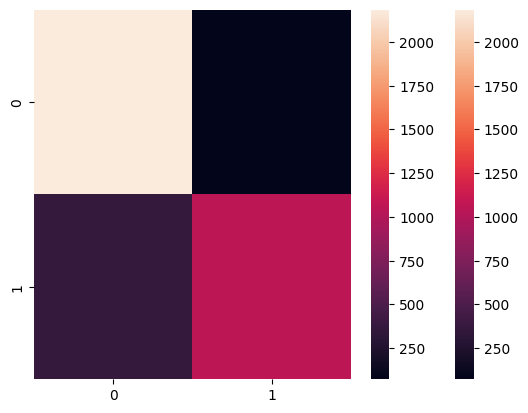

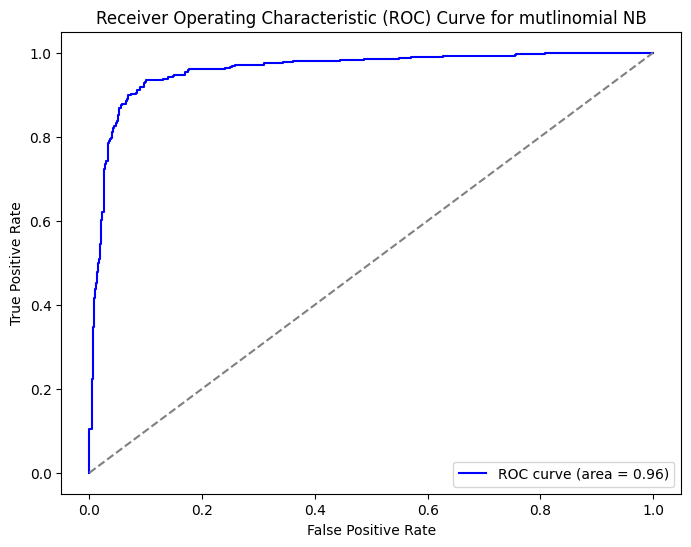


----- Fold ------
Accuracy Score of Training  : 0.8864439011138278
Precision Score of Training : 0.9366018596787827
F1 Score of Training        : 0.8413059984813971
Recall Score of Training    : 0.7636113025499656

Confusion Matrix :- 
 [[2155   75]
 [ 343 1108]]

Accuracy Score of Testing  : 0.8934782608695652
Precision Score of Testing : 0.9313725490196079
F1 Score of Testing        : 0.8532934131736527
Recall Score of Testing    : 0.787292817679558

Confusion Matrix :- 
 [[2155   75]
 [ 343 1108]]


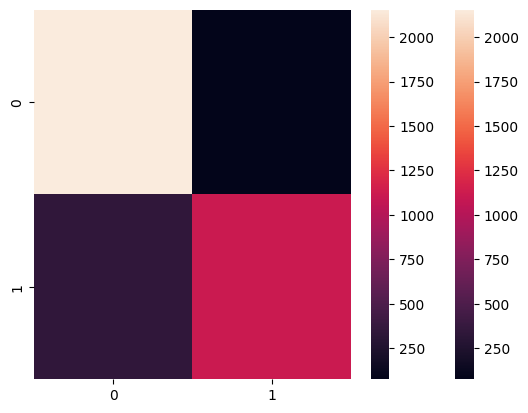

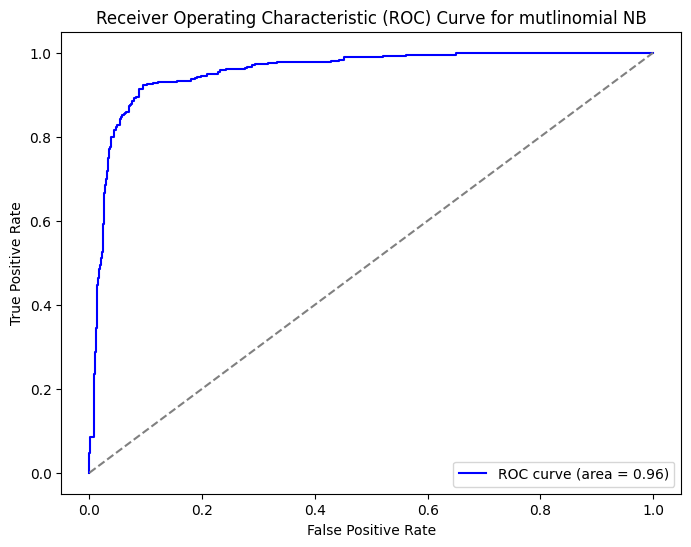


----- Fold ------
Accuracy Score of Training  : 0.8910622113556099
Precision Score of Training : 0.9350328947368421
F1 Score of Training        : 0.8500934579439252
Recall Score of Training    : 0.7793008910212474

Confusion Matrix :- 
 [[2143   79]
 [ 322 1137]]

Accuracy Score of Testing  : 0.8891304347826087
Precision Score of Testing : 0.9375
F1 Score of Testing        : 0.8411214953271028
Recall Score of Testing    : 0.7627118644067796

Confusion Matrix :- 
 [[2143   79]
 [ 322 1137]]


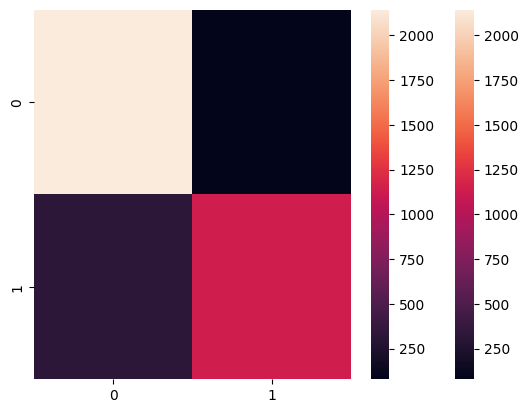

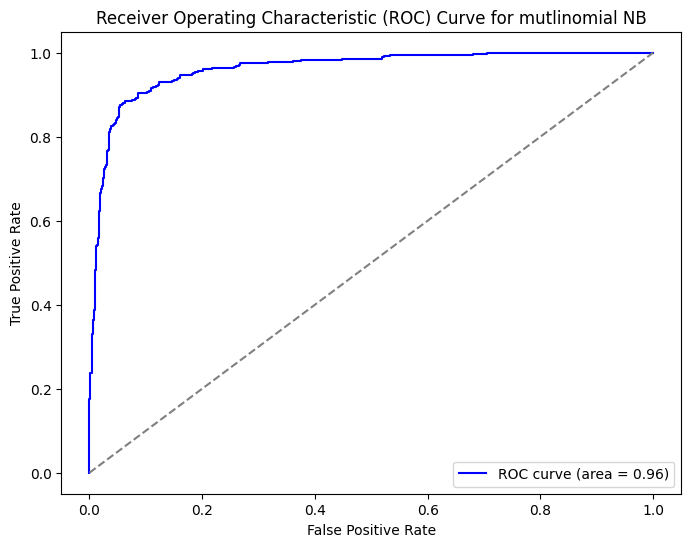


----- Fold ------
Accuracy Score of Training  : 0.8926922032056507
Precision Score of Training : 0.9342532467532467
F1 Score of Training        : 0.853540971449759
Recall Score of Training    : 0.7856655290102389

Confusion Matrix :- 
 [[2135   81]
 [ 314 1151]]

Accuracy Score of Testing  : 0.8913043478260869
Precision Score of Testing : 0.9246575342465754
F1 Score of Testing        : 0.84375
Recall Score of Testing    : 0.7758620689655172

Confusion Matrix :- 
 [[2135   81]
 [ 314 1151]]


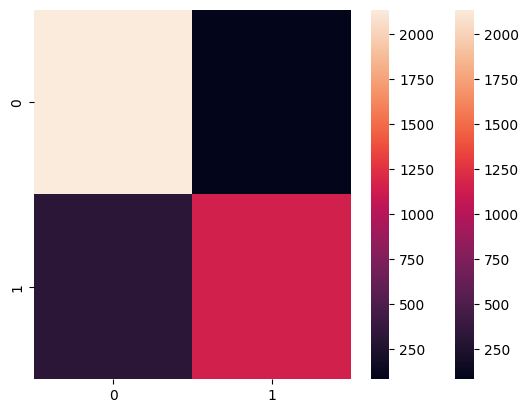

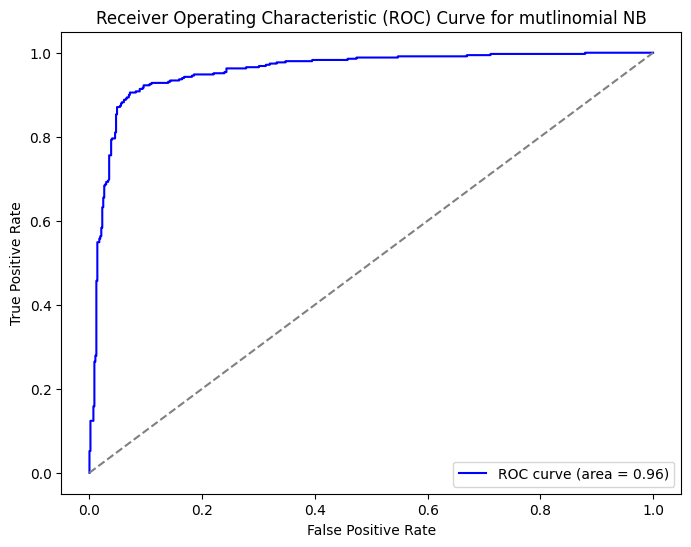


----- Fold ------
Accuracy Score of Training  : 0.8883455582722086
Precision Score of Training : 0.935672514619883
F1 Score of Training        : 0.8449641644662391
Recall Score of Training    : 0.7702888583218707

Confusion Matrix :- 
 [[2150   77]
 [ 334 1120]]

Accuracy Score of Testing  : 0.8858695652173914
Precision Score of Testing : 0.9379310344827586
F1 Score of Testing        : 0.8382126348228043
Recall Score of Testing    : 0.7576601671309192

Confusion Matrix :- 
 [[2150   77]
 [ 334 1120]]


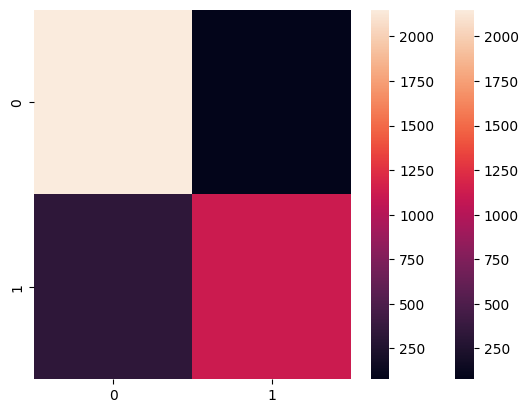

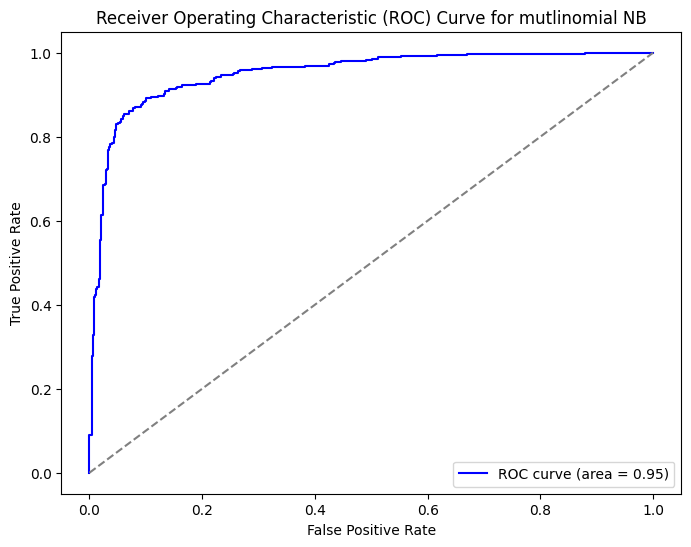

In [ ]:
model = MultinomialNB()
kf = KFold(n_splits=5,shuffle=True,random_state=42)

accuracy = []
precision = []
f1 = []
recall = []
area = []

for train_index,test_index in kf.split(x):

  x_train,x_test = x_norm.iloc[train_index],x_norm.iloc[test_index]
  y_train,y_test = y.iloc[train_index],y.iloc[test_index]

  print("\n----- Fold ------")

  model.fit(x_train,y_train)
  y_pre_train = model.predict(x_train)
  con_train_model = confusion_matrix(y_train,y_pre_train)
  sns.heatmap(con_train_model)

  accuracy_model_train = accuracy_score(y_train,y_pre_train)
  precision_model_train = precision_score(y_train,y_pre_train)
  f1_model_train = f1_score(y_train,y_pre_train)
  recall_model_train = recall_score(y_train,y_pre_train)

  print("Accuracy Score of Training  :",accuracy_model_train)
  print("Precision Score of Training :",precision_model_train)
  print("F1 Score of Training        :",f1_model_train)
  print("Recall Score of Training    :",recall_model_train)
  print("\nConfusion Matrix :- \n",con_train_model)

  y_pre_test = model.predict(x_test)
  con_test_model = confusion_matrix(y_train,y_pre_train)
  sns.heatmap(con_test_model)

  accuracy_model_test = accuracy_score(y_test,y_pre_test)
  precision_model_test = precision_score(y_test,y_pre_test)
  f1_model_test = f1_score(y_test,y_pre_test)
  recall_model_test = recall_score(y_test,y_pre_test)

  accuracy.append(accuracy_model_test)
  precision.append(precision_model_test)
  f1.append(f1_model_test)
  recall.append(recall_model_test)

  print("\nAccuracy Score of Testing  :",accuracy_model_test)
  print("Precision Score of Testing :",precision_model_test)
  print("F1 Score of Testing        :",f1_model_test)
  print("Recall Score of Testing    :",recall_model_test)
  print("\nConfusion Matrix :- \n",con_test_model)

  y_probs_model = model.predict_proba(x_test)[:, 1]

  # Calculate FPR and TPR for different thresholds
  fpr_model, tpr_model, thresholds = roc_curve(y_test, y_probs_model)

  # Calculate the AUC
  roc_auc_model = auc(fpr_model, tpr_model)

  area.append(roc_auc_model)

  # Plot the ROC curve
  plt.figure(figsize=(8, 6))
  plt.plot(fpr_model, tpr_model, color='b', label=f'ROC curve (area = {roc_auc_model:.2f})')
  plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for mutlinomial NB')
  plt.legend(loc='lower right')
  plt.show()

In [ ]:
df = pd.DataFrame({
    'KFold': list(range(1, 6)),
    'accuracy': accuracy,
    'precision': precision,
    'f1': f1,
    'recall': recall,
    'auc': area
})

mean_row = pd.DataFrame([{
    'KFold': 'Mean',
    'accuracy': np.mean(accuracy),
    'precision': np.mean(precision),
    'f1': np.mean(f1),
    'recall': np.mean(recall),
    'auc': np.mean(area)
}])

df = pd.concat([df, mean_row], ignore_index=True)

print("K Fold for Multinomial NB :-\n")
df

K Fold for Multinomial NB :-



,KFold,accuracy,precision,f1,recall,auc
0,1,0.871878,0.950331,0.829480,0.735897,0.959081
1,2,0.893478,0.931373,0.853293,0.787293,0.955598
2,3,0.889130,0.937500,0.841121,0.762712,0.960986
3,4,0.891304,0.924658,0.843750,0.775862,0.956045
4,5,0.885870,0.937931,0.838213,0.757660,0.950248
5,Mean,0.886332,0.936358,0.841171,0.763885,0.956392
